# 🧮 The Complete Math Behind LLMs
### Every Concept · Line-by-Line Code · Every Idea Visualized

---

| # | Topic | What you'll understand |
|---|-------|------------------------|
| 1 | Matrix Multiplication | Why every layer is just matmul |
| 2 | Dot Product & Cosine Similarity | The heart of attention |
| 3 | Embeddings | How words become numbers |
| 4 | Softmax + Temperature | Probabilities and creativity |
| 5 | Cross-Entropy Loss | How wrong is the model? |
| 6 | Backpropagation + Chain Rule | How gradients flow backwards |
| 7 | Gradient Descent | How weights actually update |
| 8 | Weight Initialization | Why starting values matter |
| 9 | Layer Norm vs RMSNorm | Keeping activations stable |
| 10 | Self-Attention (QKV) | The transformer's core |
| 11 | AdamW Optimizer | Why not plain SGD? |
| 12 | Learning Rate Schedules | Warmup + cosine decay |
| 13 | Tokenization | Why GPT fails on 'strawberry' |
| 14 | Perplexity | The standard LLM metric |
| 15 | Scaling Laws | How parameters and data relate |

**Zero ML library magic.** Just NumPy, PyTorch, and math you can follow.

**YouTube: SkillWisor** 🎬

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
# We use numpy for pure math demonstrations (no autograd).
# We use torch where we want autograd or GPU support.
# matplotlib for every visualization.
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from sklearn.decomposition import PCA

# ── Reproducibility ──────────────────────────────────────────────────────────
# Setting seeds means you get the same random numbers every run.
# Essential for debugging and teaching — results are predictable.
np.random.seed(42)
torch.manual_seed(42)

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams['figure.facecolor'] = '#0d1117'   # dark background
plt.rcParams['axes.facecolor']   = '#161b22'   # dark axes
plt.rcParams['text.color']       = '#e6edf3'   # light text
plt.rcParams['axes.labelcolor']  = '#e6edf3'
plt.rcParams['xtick.color']      = '#8b949e'
plt.rcParams['ytick.color']      = '#8b949e'
plt.rcParams['axes.edgecolor']   = '#30363d'
plt.rcParams['grid.color']       = '#21262d'
plt.rcParams['axes.titlecolor']  = '#e6edf3'

print('✅ All imports ready. Let\'s build LLM math from scratch!')

✅ All imports ready. Let's build LLM math from scratch!


---
# 🔢 Chapter 1: Matrix Multiplication
### The single operation that powers every layer in every neural network

A neural network layer is literally just:
```
output = input × weight_matrix + bias
```
That's matrix multiplication. Every attention head, every FFN, every embedding lookup — matmul.

In [2]:
# ── What is matrix multiplication? ───────────────────────────────────────────
# Given matrix A (m×k) and matrix B (k×n),
# the result C (m×n) has C[i,j] = sum of A[i,:] * B[:,j]
# i.e., the DOT PRODUCT of row i of A with column j of B.

# Simple 2x3 × 3x2 example — let's trace every cell by hand
A = np.array([[1, 2, 3],
              [4, 5, 6]])   # shape: (2, 3)  — 2 rows, 3 columns

B = np.array([[7,  8],
              [9,  10],
              [11, 12]])    # shape: (3, 2)  — 3 rows, 2 columns

# Result will be shape (2, 2)  — (rows of A) × (cols of B)
C = A @ B  # Python's @ operator = matrix multiply

print('Matrix A (2×3):')
print(A)
print('\nMatrix B (3×2):')
print(B)
print('\nC = A @ B  (2×2):')
print(C)

# ── Trace cell C[0,0] step by step ───────────────────────────────────────────
# C[0,0] = row 0 of A dotted with column 0 of B
#         = 1×7 + 2×9 + 3×11
#         = 7 + 18 + 33 = 58
print(f'\nTrace C[0,0]: 1×7 + 2×9 + 3×11 = {1*7} + {2*9} + {3*11} = {1*7+2*9+3*11}')
print(f'Trace C[1,1]: 4×8 + 5×10 + 6×12 = {4*8} + {5*10} + {6*12} = {4*8+5*10+6*12}')

# ── Why matmul = neural network layer ────────────────────────────────────────
# In a neural network:
#   input  X: (batch_size, input_dim)    = e.g. (32, 784) for MNIST
#   weight W: (input_dim, output_dim)   = e.g. (784, 128)
#   bias   b: (output_dim,)             = e.g. (128,)
#   output:   (batch_size, output_dim)  = e.g. (32, 128)

batch = 4    # 4 examples at once
in_d  = 784  # 28×28 pixels
out_d = 128  # 128 neurons in this layer

X = np.random.randn(batch, in_d)    # 4 images, each 784 pixels
W = np.random.randn(in_d,  out_d)   # weight matrix
b = np.random.randn(out_d)          # bias vector

# One matmul computes ALL 4 images through ALL 128 neurons simultaneously
output = X @ W + b  # shape: (4, 128)

print(f'\n── Neural network layer as matmul ──')
print(f'X shape:      {X.shape}  (4 images × 784 pixels)')
print(f'W shape:      {W.shape}  (784 inputs × 128 neurons)')
print(f'output shape: {output.shape}  (4 images × 128 neuron activations)')
print(f'\n💡 ONE @ computes {batch} × {out_d} = {batch*out_d} dot products simultaneously!')
print(f'   This is why GPUs are so powerful — they do millions of these in parallel.')

Matrix A (2×3):
[[1 2 3]
 [4 5 6]]

Matrix B (3×2):
[[ 7  8]
 [ 9 10]
 [11 12]]

C = A @ B  (2×2):
[[ 58  64]
 [139 154]]

Trace C[0,0]: 1×7 + 2×9 + 3×11 = 7 + 18 + 33 = 58
Trace C[1,1]: 4×8 + 5×10 + 6×12 = 32 + 50 + 72 = 154

── Neural network layer as matmul ──
X shape:      (4, 784)  (4 images × 784 pixels)
W shape:      (784, 128)  (784 inputs × 128 neurons)
output shape: (4, 128)  (4 images × 128 neuron activations)

💡 ONE @ computes 4 × 128 = 512 dot products simultaneously!
   This is why GPUs are so powerful — they do millions of these in parallel.


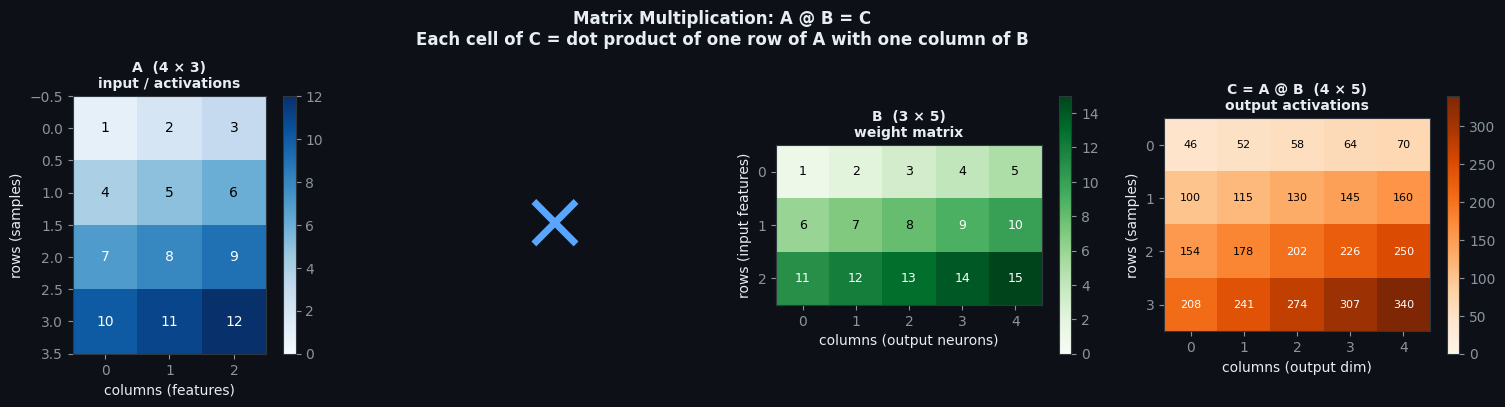

💡 Shape rule: (m×k) @ (k×n) = (m×n)
   The INNER dimensions must match (both k).
   The OUTER dimensions become the result shape.


In [3]:
# ── Visualize matrix multiplication ──────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Small example for visualization
A_v = np.array([[1,2,3],[4,5,6],[7,8,9],[10,11,12]], dtype=float)   # 4×3
B_v = np.array([[1,2,3,4,5],[6,7,8,9,10],[11,12,13,14,15]], dtype=float)  # 3×5
C_v = A_v @ B_v  # 4×5

vmin_A, vmax_A = A_v.min(), A_v.max()
vmin_B, vmax_B = B_v.min(), B_v.max()

im0 = axes[0].imshow(A_v, cmap='Blues', vmin=0)
axes[0].set_title('A  (4 × 3)\ninput / activations', fontweight='bold', fontsize=10)
axes[0].set_xlabel('columns (features)')
axes[0].set_ylabel('rows (samples)')
for i in range(4):
    for j in range(3):
        axes[0].text(j, i, f'{int(A_v[i,j])}', ha='center', va='center',
                    fontsize=10, color='white' if A_v[i,j]>6 else 'black')
plt.colorbar(im0, ax=axes[0])

axes[1].text(0.5, 0.5, '×', ha='center', va='center',
            fontsize=60, transform=axes[1].transAxes, color='#58a6ff')
axes[1].axis('off')
axes[1].set_title(' ')

im2 = axes[2].imshow(B_v, cmap='Greens', vmin=0)
axes[2].set_title('B  (3 × 5)\nweight matrix', fontweight='bold', fontsize=10)
axes[2].set_xlabel('columns (output neurons)')
axes[2].set_ylabel('rows (input features)')
for i in range(3):
    for j in range(5):
        axes[2].text(j, i, f'{int(B_v[i,j])}', ha='center', va='center',
                    fontsize=9, color='white' if B_v[i,j]>8 else 'black')
plt.colorbar(im2, ax=axes[2])

im3 = axes[3].imshow(C_v, cmap='Oranges', vmin=0)
axes[3].set_title('C = A @ B  (4 × 5)\noutput activations', fontweight='bold', fontsize=10)
axes[3].set_xlabel('columns (output dim)')
axes[3].set_ylabel('rows (samples)')
for i in range(4):
    for j in range(5):
        axes[3].text(j, i, f'{int(C_v[i,j])}', ha='center', va='center',
                    fontsize=8, color='white' if C_v[i,j]>200 else 'black')
plt.colorbar(im3, ax=axes[3])

plt.suptitle('Matrix Multiplication: A @ B = C\nEach cell of C = dot product of one row of A with one column of B',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Shape rule: (m×k) @ (k×n) = (m×n)')
print('   The INNER dimensions must match (both k).')
print('   The OUTER dimensions become the result shape.')

---
# 🎯 Chapter 2: Dot Product & Cosine Similarity
### The heart of the attention mechanism

In [4]:
# ── Dot Product ───────────────────────────────────────────────────────────────
# The dot product of two vectors a and b:
# a · b = a[0]*b[0] + a[1]*b[1] + ... + a[n]*b[n]
#       = |a| * |b| * cos(θ)   where θ is the angle between them
#
# This means:
#   Large positive → vectors point in same direction (similar)
#   Near zero      → vectors are perpendicular (unrelated)
#   Large negative → vectors point opposite directions (dissimilar)

# Example: word vectors (simplified 2D for visualization)
# In real LLMs these are 128-8192 dimensional

vectors = {
    'king':    np.array([0.9, 0.8]),
    'queen':   np.array([0.85, 0.75]),
    'man':     np.array([0.7, -0.2]),
    'woman':   np.array([0.65, -0.15]),
    'cat':     np.array([-0.8, 0.5]),
    'dog':     np.array([-0.75, 0.45]),
    'python':  np.array([-0.3, -0.9]),
    'java':    np.array([-0.25, -0.85]),
}

def dot_product(a, b):
    # Element-wise multiply, then sum
    return np.sum(a * b)

def cosine_similarity(a, b):
    # Normalize the dot product by the magnitudes of both vectors
    # This gives a value between -1 and +1, independent of vector length
    dot   = dot_product(a, b)
    mag_a = np.linalg.norm(a)  # √(a[0]² + a[1]² + ...)
    mag_b = np.linalg.norm(b)
    return dot / (mag_a * mag_b + 1e-9)  # 1e-9 prevents division by zero

print('🔢 Dot products and cosine similarities between word pairs:\n')
pairs = [('king','queen'), ('man','woman'), ('cat','dog'),
         ('python','java'), ('king','cat'), ('king','python')]

for w1, w2 in pairs:
    v1, v2 = vectors[w1], vectors[w2]
    dp  = dot_product(v1, v2)
    cos = cosine_similarity(v1, v2)
    angle = np.degrees(np.arccos(np.clip(cos, -1, 1)))
    print(f'  {w1:8} ↔ {w2:8}: dot={dp:.3f}  cosine={cos:.3f}  angle={angle:.1f}°')

print()
print('💡 Notice:')
print('   king↔queen : very similar (close vectors)')
print('   king↔cat   : different categories (lower similarity)')
print('   king↔python: very different (near zero)')

🔢 Dot products and cosine similarities between word pairs:

  king     ↔ queen   : dot=1.365  cosine=1.000  angle=0.2°
  man      ↔ woman   : dot=0.485  cosine=0.999  angle=3.0°
  cat      ↔ dog     : dot=0.825  cosine=1.000  angle=1.0°
  python   ↔ java    : dot=0.840  cosine=0.999  angle=2.0°
  king     ↔ cat     : dot=-0.320  cosine=-0.282  angle=106.4°
  king     ↔ python  : dot=-0.990  cosine=-0.867  angle=150.1°

💡 Notice:
   king↔queen : very similar (close vectors)
   king↔cat   : different categories (lower similarity)
   king↔python: very different (near zero)


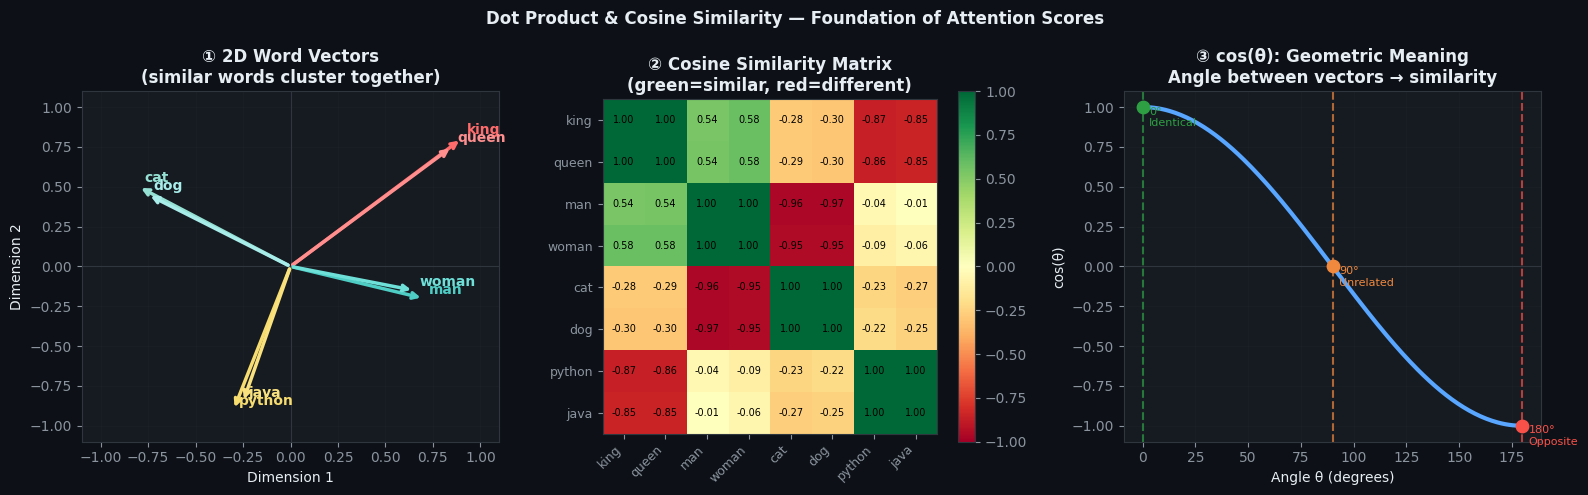

In [5]:
# ── Visualize dot products and similarity ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. 2D vector space
colors = {'king':'#FF6B6B','queen':'#FF8E8E','man':'#4ECDC4','woman':'#6EE0D8',
          'cat':'#95E1D3','dog':'#A8EDEA','python':'#F7DC6F','java':'#F9E17E'}
ax = axes[0]
for word, vec in vectors.items():
    ax.annotate('', xy=vec, xytext=(0,0),
               arrowprops=dict(arrowstyle='->', color=colors[word], lw=2.5))
    ax.text(vec[0]+0.03, vec[1]+0.03, word, fontsize=10,
           color=colors[word], fontweight='bold')
ax.axhline(0, color='#30363d', lw=0.8)
ax.axvline(0, color='#30363d', lw=0.8)
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.set_title('① 2D Word Vectors\n(similar words cluster together)', fontweight='bold')
ax.set_xlabel('Dimension 1'); ax.set_ylabel('Dimension 2')
ax.grid(True, alpha=0.3)

# 2. Cosine similarity heatmap
words_list = list(vectors.keys())
n = len(words_list)
sim_matrix = np.zeros((n, n))
for i, w1 in enumerate(words_list):
    for j, w2 in enumerate(words_list):
        sim_matrix[i,j] = cosine_similarity(vectors[w1], vectors[w2])

im = axes[1].imshow(sim_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1].set_xticks(range(n)); axes[1].set_yticks(range(n))
axes[1].set_xticklabels(words_list, rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(words_list, fontsize=9)
for i in range(n):
    for j in range(n):
        axes[1].text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center',
                   fontsize=7, color='black')
axes[1].set_title('② Cosine Similarity Matrix\n(green=similar, red=different)', fontweight='bold')
plt.colorbar(im, ax=axes[1])

# 3. Geometric interpretation
ax3 = axes[2]
theta_range = np.linspace(0, np.pi, 200)
cos_values  = np.cos(theta_range)
ax3.plot(np.degrees(theta_range), cos_values, '#58a6ff', lw=3)
# Mark key angles
key_angles = [(0,'0°\nIdentical',1,'#2ea043'),
              (90,'90°\nUnrelated',0,'#f0883e'),
              (180,'180°\nOpposite',-1,'#f85149')]
for ang, label, val, col in key_angles:
    ax3.axvline(ang, color=col, ls='--', alpha=0.7)
    ax3.scatter([ang],[val], color=col, s=80, zorder=5)
    ax3.text(ang+3, val-0.12, label, color=col, fontsize=8)
ax3.set_title('③ cos(θ): Geometric Meaning\nAngle between vectors → similarity', fontweight='bold')
ax3.set_xlabel('Angle θ (degrees)')
ax3.set_ylabel('cos(θ)')
ax3.axhline(0, color='#30363d', lw=0.8)
ax3.grid(True, alpha=0.3)

plt.suptitle('Dot Product & Cosine Similarity — Foundation of Attention Scores',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 📦 Chapter 3: Embeddings
### How words (and tokens) become numbers the network can work with

In [6]:
# ── What is an embedding? ─────────────────────────────────────────────────────
# An embedding is a lookup table.
# vocab_size rows (one per token), d_model columns (embedding dimensions).
# Given a token ID (integer), we look up that row → a dense vector.
#
# Before embeddings: token "cat" → ID 42 → one-hot [0,0,...,1,...,0] (50000 dim)
# After embeddings:  token "cat" → ID 42 → look up row 42 → [0.3, -0.5, ..., 0.8] (128 dim)
#
# The embedding values are LEARNED during training.
# Similar words end up with similar embedding vectors.

VOCAB_SIZE   = 10   # tiny vocabulary for demonstration
D_MODEL      = 8    # embedding dimension (real LLMs: 512–8192)

# The embedding table: shape (vocab_size, d_model)
# Each row = the vector representation for that token
embedding_table = nn.Embedding(VOCAB_SIZE, D_MODEL)

# Lookup: give token IDs, get vectors
token_ids = torch.tensor([0, 3, 7, 2])  # a sequence of 4 tokens

# This is literally just indexing into the weight matrix
# embedding_table(token_ids) == embedding_table.weight[token_ids]
embeddings = embedding_table(token_ids)  # shape: (4, 8)

print('Embedding table shape:', embedding_table.weight.shape)
print(f'  → {VOCAB_SIZE} tokens × {D_MODEL} dimensions')
print(f'\nToken IDs: {token_ids.tolist()}')
print(f'Embeddings shape: {embeddings.shape}  (4 tokens × {D_MODEL} dims)')
print(f'\nEmbedding for token 0:')
print(f'  {embeddings[0].detach().numpy().round(3)}')

# ── Why not one-hot? ──────────────────────────────────────────────────────────
# One-hot: vocab_size dimensions (e.g. 50,000)
#   → sparse: 49,999 zeros, 1 one
#   → no notion of similarity: all tokens equally distant
#   → huge memory and compute
#
# Embedding: d_model dimensions (e.g. 512)
#   → dense: all values carry information
#   → similarity: similar tokens learn similar vectors
#   → 100x smaller

print(f'\n── Size comparison ──')
vocab = 50000
print(f'One-hot vector    : {vocab:,} dimensions (sparse, {vocab-1} zeros per token)')
print(f'Embedding vector  : 512 dimensions (dense, all informative)')
print(f'Size reduction    : {vocab//512}× smaller')

Embedding table shape: torch.Size([10, 8])
  → 10 tokens × 8 dimensions

Token IDs: [0, 3, 7, 2]
Embeddings shape: torch.Size([4, 8])  (4 tokens × 8 dims)

Embedding for token 0:
  [ 1.927  1.487  0.901 -2.106  0.678 -1.235 -0.043 -1.605]

── Size comparison ──
One-hot vector    : 50,000 dimensions (sparse, 49999 zeros per token)
Embedding vector  : 512 dimensions (dense, all informative)
Size reduction    : 97× smaller


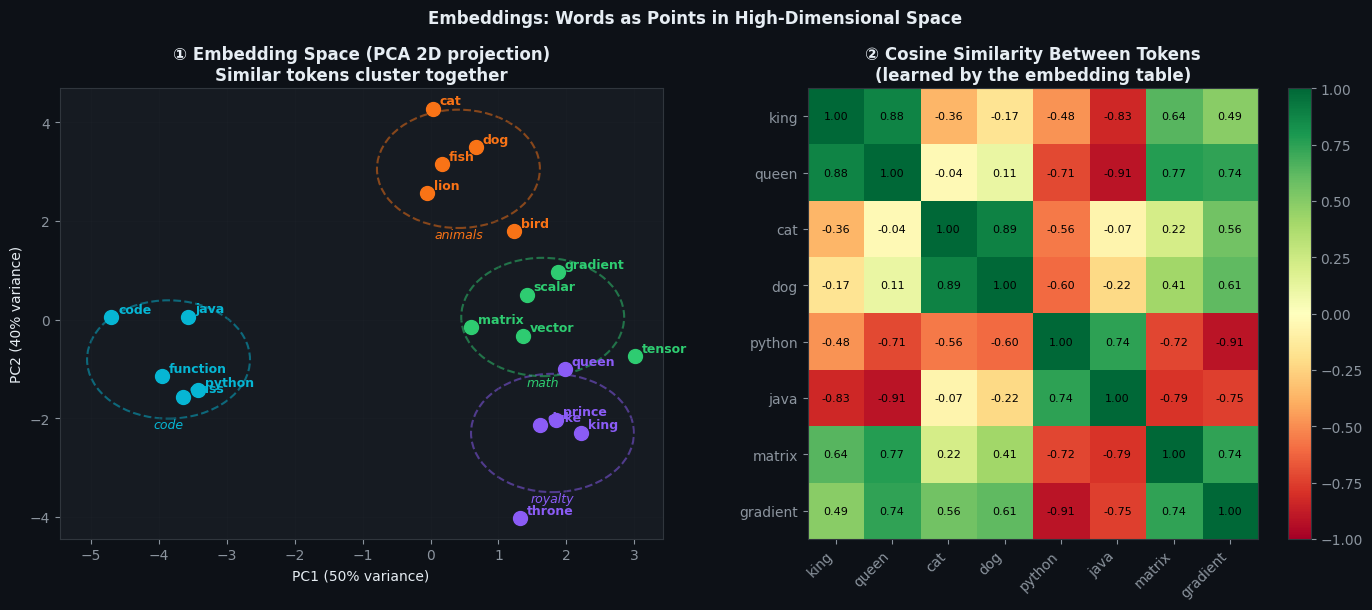

💡 The famous word2vec result:
   king - man + woman ≈ queen
   This works because embeddings encode semantic relationships as geometry!


In [8]:
# ── Simulate trained embeddings for visualization ─────────────────────────────
# We'll create embeddings with semantic structure baked in
# (in real training, the network learns this structure from data)

# 20 tokens with semantic clusters
tokens = [
    # Animals
    'cat','dog','bird','fish','lion',
    # Royalty
    'king','queen','prince','duke','throne',
    # Code
    'python','java','code','function','class',
    # Math
    'matrix','vector','scalar','tensor','gradient'
]

# Create cluster-based 16-dim embeddings
np.random.seed(7)
cluster_centers = {
    'animals': np.array([3, 2] + [0]*14, dtype=float),
    'royalty': np.array([-3, 2] + [0]*14, dtype=float),
    'code':    np.array([0, -3] + [0]*14, dtype=float),
    'math':    np.array([0, 3] + [0]*14, dtype=float),
}
categories = ['animals']*5 + ['royalty']*5 + ['code']*5 + ['math']*5
cat_colors  = {'animals':'#F97316','royalty':'#8B5CF6','code':'#06B6D4','math':'#2ECC71'}

all_embs = []
for i, (tok, cat) in enumerate(zip(tokens, categories)):
    center = cluster_centers[cat].copy()
    center[:2] += np.random.randn(2) * 0.8   # add noise to first 2 dims
    center[2:]  = np.random.randn(14) * 0.3  # random for other dims
    all_embs.append(center)

all_embs = np.array(all_embs)   # (20, 16)

# PCA to 2D for visualization
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(all_embs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. 2D projection
for i, (tok, cat) in enumerate(zip(tokens, categories)):
    x, y = coords_2d[i]
    color = cat_colors[cat]
    axes[0].scatter(x, y, color=color, s=100, zorder=5)
    axes[0].annotate(tok, (x, y), textcoords='offset points',
                    xytext=(5, 3), fontsize=9, color=color, fontweight='bold')

# Draw convex hulls (cluster regions)
from matplotlib.patches import FancyArrowPatch
for cat, col in cat_colors.items():
    idxs = [i for i, c in enumerate(categories) if c==cat]
    pts  = coords_2d[idxs]
    axes[0].add_patch(plt.Circle(pts.mean(0), 1.2, fill=False,
                                edgecolor=col, ls='--', lw=1.5, alpha=0.5))
    axes[0].text(*pts.mean(0)+[0,-1.4], cat, ha='center',
                color=col, fontsize=9, style='italic')

axes[0].set_title('① Embedding Space (PCA 2D projection)\nSimilar tokens cluster together', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% variance)')
axes[0].grid(True, alpha=0.25)

# 2. Similarity heatmap for a subset
subset  = ['king','queen','cat','dog','python','java','matrix','gradient']
sub_idx = [tokens.index(t) for t in subset]
sub_emb = all_embs[sub_idx]

# Normalize each embedding to unit length for cosine sim
sub_emb_n = sub_emb / (np.linalg.norm(sub_emb, axis=1, keepdims=True) + 1e-9)
sim = sub_emb_n @ sub_emb_n.T  # (8,8) cosine similarity matrix

im = axes[1].imshow(sim, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(subset))); axes[1].set_yticks(range(len(subset)))
axes[1].set_xticklabels(subset, rotation=45, ha='right', fontsize=10)
axes[1].set_yticklabels(subset, fontsize=10)
for i in range(len(subset)):
    for j in range(len(subset)):
        axes[1].text(j, i, f'{sim[i,j]:.2f}', ha='center', va='center', fontsize=8, color='black')
axes[1].set_title('② Cosine Similarity Between Tokens\n(learned by the embedding table)', fontweight='bold')
plt.colorbar(im, ax=axes[1])

plt.suptitle('Embeddings: Words as Points in High-Dimensional Space', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 The famous word2vec result:')
print('   king - man + woman ≈ queen')
print('   This works because embeddings encode semantic relationships as geometry!')

---
# 🌡️ Chapter 4: Softmax + Temperature
### Turning raw scores into probabilities — and controlling creativity

In [9]:
# ── What is Softmax? ──────────────────────────────────────────────────────────
# A neural network outputs RAW SCORES (logits) — any real number.
# Softmax converts these into PROBABILITIES that sum to 1.
#
# Formula:
#   softmax(x_i) = exp(x_i) / sum(exp(x_j) for all j)
#
# Properties:
#   - All outputs are between 0 and 1
#   - All outputs sum to exactly 1.0
#   - Larger inputs → larger probabilities (monotone)
#   - Differences are AMPLIFIED: the highest score gets disproportionately more

# Example: model predicts the next word after "The cat sat on the"
vocab_words = ['mat', 'roof', 'floor', 'table', 'chair', 'ground', 'stairs', 'bed']
logits      = np.array([4.2, 1.1, 2.8, 0.5, 1.9, 3.1, 0.2, 1.4])

def softmax(x, temperature=1.0):
    # Step 1: Divide by temperature to control sharpness
    x_scaled = x / temperature

    # Step 2: Subtract max for numerical stability
    # Without this, exp(large_number) → inf → NaN
    # Subtracting max doesn't change the result (it cancels in numerator and denominator)
    x_shifted = x_scaled - np.max(x_scaled)

    # Step 3: Exponentiate (makes all values positive)
    exp_x = np.exp(x_shifted)

    # Step 4: Normalize (divide by sum so they add up to 1)
    return exp_x / np.sum(exp_x)

probs = softmax(logits)

print('📊 Next word prediction after "The cat sat on the":')
print(f'{"Word":>8} | {"Logit":>8} | {"Probability":>12} | Bar')
print('-' * 55)
for word, logit, prob in sorted(zip(vocab_words, logits, probs),
                                 key=lambda x: -x[2]):
    bar = '█' * int(prob * 40)
    print(f'{word:>8} | {logit:>8.1f} | {prob:>11.1%} | {bar}')

print(f'\nSum of probabilities: {probs.sum():.6f}  (must equal 1.0)')

📊 Next word prediction after "The cat sat on the":
    Word |    Logit |  Probability | Bar
-------------------------------------------------------
     mat |      4.2 |       54.7% | █████████████████████
  ground |      3.1 |       18.2% | ███████
   floor |      2.8 |       13.5% | █████
   chair |      1.9 |        5.5% | ██
     bed |      1.4 |        3.3% | █
    roof |      1.1 |        2.5% | 
   table |      0.5 |        1.4% | 
  stairs |      0.2 |        1.0% | 

Sum of probabilities: 1.000000  (must equal 1.0)


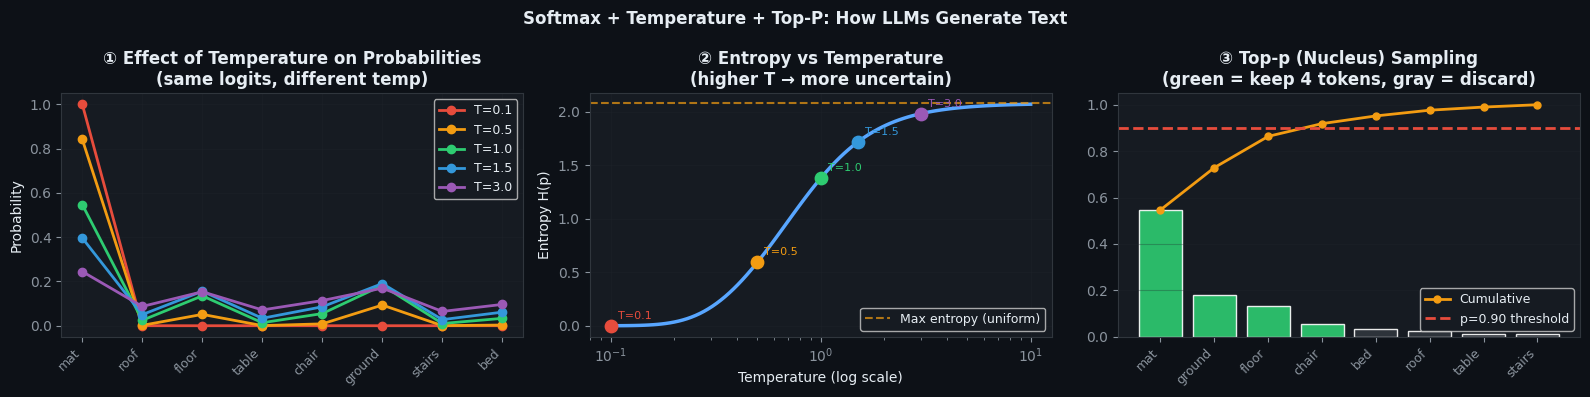

💡 Key takeaways:
   Low  temp  → model is confident, deterministic (boring but safe)
   High temp  → model is creative, varied (may hallucinate)
   Top-p      → adaptively keeps tokens covering 90% of probability mass


In [10]:
# ── Temperature — the creativity knob ────────────────────────────────────────
# softmax(x / T)  where T is temperature
#
# T → 0: winner-takes-all (greedy, always pick highest logit)
# T = 1: raw softmax (standard)
# T > 1: flatter distribution (more random, more creative)
# T → ∞: uniform distribution (completely random)
#
# Claude, ChatGPT, Gemini all use temperature when generating text.
# Temperature 0 = deterministic output (same every time)
# Temperature 0.7-0.9 = balanced (most common default)
# Temperature 1.5+ = very creative / sometimes incoherent

temperatures = [0.1, 0.5, 1.0, 1.5, 3.0]
temp_probs   = {T: softmax(logits, T) for T in temperatures}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Probability distributions at different temps
x = np.arange(len(vocab_words))
colors_T = ['#E74C3C','#F39C12','#2ECC71','#3498DB','#9B59B6']

for i, (T, c) in enumerate(zip(temperatures, colors_T)):
    axes[0].plot(x, temp_probs[T], marker='o', lw=2, color=c,
                label=f'T={T}', ms=6)

axes[0].set_xticks(x)
axes[0].set_xticklabels(vocab_words, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Probability')
axes[0].set_title('① Effect of Temperature on Probabilities\n(same logits, different temp)', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# 2. Entropy vs temperature
def entropy(probs):
    # Entropy = measure of uncertainty / randomness
    # H = -sum(p * log(p))
    # Low entropy = confident (spiky distribution)
    # High entropy = uncertain (flat distribution)
    return -np.sum(probs * np.log(np.maximum(probs, 1e-12)))

T_range     = np.logspace(-1, 1, 100)
entropies   = [entropy(softmax(logits, T)) for T in T_range]

axes[1].semilogx(T_range, entropies, '#58a6ff', lw=2.5)
for T, c in zip(temperatures, colors_T):
    e = entropy(softmax(logits, T))
    axes[1].scatter([T], [e], color=c, s=80, zorder=5)
    axes[1].annotate(f'T={T}', (T, e), textcoords='offset points',
                   xytext=(5, 5), fontsize=8, color=c)
axes[1].axhline(np.log(8), color='#F39C12', ls='--', alpha=0.7,
               label='Max entropy (uniform)')
axes[1].set_xlabel('Temperature (log scale)')
axes[1].set_ylabel('Entropy H(p)')
axes[1].set_title('② Entropy vs Temperature\n(higher T → more uncertain)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# 3. Top-p (nucleus) sampling
def top_p_mask(probs, p=0.9):
    # Sort by probability descending
    sorted_idx   = np.argsort(probs)[::-1]
    sorted_probs = probs[sorted_idx]
    # Find cutoff where cumulative sum exceeds p
    cumulative   = np.cumsum(sorted_probs)
    cutoff       = np.searchsorted(cumulative, p) + 1
    # Keep only top tokens
    mask         = np.zeros(len(probs), dtype=bool)
    mask[sorted_idx[:cutoff]] = True
    return mask, cutoff

probs_t1     = softmax(logits, temperature=1.0)
mask, cutoff = top_p_mask(probs_t1, p=0.90)

sorted_idx   = np.argsort(probs_t1)[::-1]
sorted_probs = probs_t1[sorted_idx]
cum_probs    = np.cumsum(sorted_probs)
sorted_words = [vocab_words[i] for i in sorted_idx]

bar_colors = ['#2ECC71' if i < cutoff else '#30363d' for i in range(len(vocab_words))]
bars = axes[2].bar(range(len(vocab_words)), sorted_probs, color=bar_colors,
                  alpha=0.9, edgecolor='white')
axes[2].plot(range(len(vocab_words)), cum_probs, '#F39C12', lw=2, marker='o',
            ms=5, label='Cumulative')
axes[2].axhline(0.9, color='#E74C3C', ls='--', lw=2, label='p=0.90 threshold')
axes[2].set_xticks(range(len(vocab_words)))
axes[2].set_xticklabels(sorted_words, rotation=45, ha='right', fontsize=9)
axes[2].set_title(f'③ Top-p (Nucleus) Sampling\n(green = keep {cutoff} tokens, gray = discard)', fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Softmax + Temperature + Top-P: How LLMs Generate Text',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Key takeaways:')
print('   Low  temp  → model is confident, deterministic (boring but safe)')
print('   High temp  → model is creative, varied (may hallucinate)')
print('   Top-p      → adaptively keeps tokens covering 90% of probability mass')

---
# 📉 Chapter 5: Cross-Entropy Loss
### Measuring how wrong the model is — mathematically

In [11]:
# ── What is Cross-Entropy Loss? ───────────────────────────────────────────────
# Given the model's predicted probability distribution and the TRUE label,
# cross-entropy measures "how surprised" the model would be by the truth.
#
# Formula:
#   CE = -log(probability assigned to the correct class)
#
# If model says P(correct) = 1.0  → CE = -log(1.0) = 0        (perfect!)
# If model says P(correct) = 0.5  → CE = -log(0.5) = 0.693    (okay)
# If model says P(correct) = 0.1  → CE = -log(0.1) = 2.303    (bad)
# If model says P(correct) → 0    → CE → ∞                    (catastrophic)

def cross_entropy_loss(predicted_probs, true_label):
    # Get the probability assigned to the correct label
    correct_prob = predicted_probs[true_label]
    # Loss = negative log of that probability
    # Negative because log of values 0-1 is negative, we want a positive loss
    loss = -np.log(correct_prob + 1e-12)  # 1e-12 prevents log(0) = -inf
    return loss

# Scenario: true label is 'mat' (index 0)
true_label = 0  # 'mat'

# Different quality predictions
scenarios = [
    ('Perfect',   np.array([0.99, 0.003, 0.003, 0.001, 0.001, 0.001, 0.001, 0.001])),
    ('Good',      np.array([0.80, 0.05, 0.05,  0.03,  0.03,  0.02,  0.01,  0.01 ])),
    ('Mediocre',  np.array([0.40, 0.15, 0.12,  0.10,  0.09,  0.07,  0.04,  0.03 ])),
    ('Bad',       np.array([0.10, 0.20, 0.18,  0.15,  0.14,  0.10,  0.08,  0.05 ])),
    ('Terrible',  np.array([0.01, 0.25, 0.20,  0.18,  0.15,  0.12,  0.07,  0.02 ])),
]

print('📊 Cross-Entropy Loss: how wrong is the prediction?')
print(f'   True answer: "{vocab_words[true_label]}"\n')
print(f'{"Scenario":>12} | {"P(correct)":>12} | {"Loss":>8} | Intuition')
print('-' * 60)

for name, probs in scenarios:
    loss = cross_entropy_loss(probs, true_label)
    print(f'{name:>12} | {probs[true_label]:>11.1%} | {loss:>8.4f} | ', end='')
    if loss < 0.1:   print('✅ Excellent')
    elif loss < 0.5: print('🟢 Good')
    elif loss < 1.5: print('🟡 Mediocre')
    elif loss < 2.5: print('🔴 Bad')
    else:            print('💀 Terrible')

print(f'\n💡 For a random model with {len(vocab_words)} classes:')
random_prob = 1.0 / len(vocab_words)
print(f'   P(correct) = 1/{len(vocab_words)} = {random_prob:.3f}')
print(f'   Expected loss = -log({random_prob:.3f}) = {-np.log(random_prob):.3f}')
print(f'   ≈ log(vocab_size) — this is the "starting point" for any LLM')

# For LLMs with vocabulary ~50,000 tokens:
print(f'\n   For real LLM (vocab=50,000):')
print(f'   Random baseline loss = log(50000) = {np.log(50000):.2f}')

📊 Cross-Entropy Loss: how wrong is the prediction?
   True answer: "mat"

    Scenario |   P(correct) |     Loss | Intuition
------------------------------------------------------------
     Perfect |       99.0% |   0.0101 | ✅ Excellent
        Good |       80.0% |   0.2231 | 🟢 Good
    Mediocre |       40.0% |   0.9163 | 🟡 Mediocre
         Bad |       10.0% |   2.3026 | 🔴 Bad
    Terrible |        1.0% |   4.6052 | 💀 Terrible

💡 For a random model with 8 classes:
   P(correct) = 1/8 = 0.125
   Expected loss = -log(0.125) = 2.079
   ≈ log(vocab_size) — this is the "starting point" for any LLM

   For real LLM (vocab=50,000):
   Random baseline loss = log(50000) = 10.82


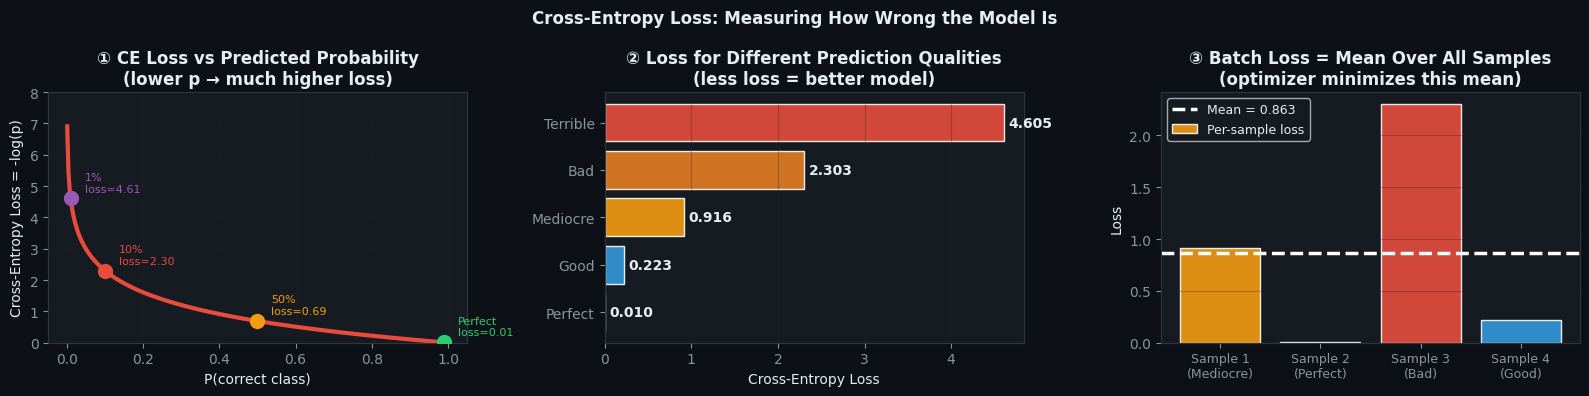

In [12]:
# ── Visualize cross-entropy ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. -log(p) curve
p_range = np.linspace(0.001, 1.0, 300)
ce_vals = -np.log(p_range)
axes[0].plot(p_range, ce_vals, '#E74C3C', lw=3)
key_pts = [(0.99,'#2ECC71','Perfect'),(0.5,'#F39C12','50%'),(0.1,'#E74C3C','10%'),(0.01,'#9B59B6','1%')]
for p, col, lbl in key_pts:
    axes[0].scatter([p],[-np.log(p)], color=col, s=100, zorder=5)
    axes[0].annotate(f'{lbl}\nloss={-np.log(p):.2f}', (p,-np.log(p)),
                   textcoords='offset points', xytext=(10,5), fontsize=8, color=col)
axes[0].set_xlabel('P(correct class)')
axes[0].set_ylabel('Cross-Entropy Loss = -log(p)')
axes[0].set_title('① CE Loss vs Predicted Probability\n(lower p → much higher loss)', fontweight='bold')
axes[0].set_ylim(0, 8); axes[0].grid(True, alpha=0.3)

# 2. Probability bars for each scenario
names = [s[0] for s in scenarios]
losses= [cross_entropy_loss(s[1], true_label) for s in scenarios]
bar_cols = ['#2ECC71','#3498DB','#F39C12','#E67E22','#E74C3C']
bars = axes[1].barh(range(len(names)), losses, color=bar_cols, alpha=0.9, edgecolor='white')
for bar, loss, name in zip(bars, losses, names):
    axes[1].text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
               f'{loss:.3f}', va='center', fontsize=10, fontweight='bold')
axes[1].set_yticks(range(len(names)))
axes[1].set_yticklabels(names, fontsize=10)
axes[1].set_xlabel('Cross-Entropy Loss')
axes[1].set_title('② Loss for Different Prediction Qualities\n(less loss = better model)', fontweight='bold')
axes[1].grid(True, axis='x', alpha=0.3)

# 3. Average loss over a training batch
# In practice, we compute the mean loss over a BATCH of examples
batch_preds  = np.array([scenarios[2][1], scenarios[0][1],
                          scenarios[3][1], scenarios[1][1]])
batch_labels = np.array([0, 0, 0, 0])
batch_losses = [-np.log(batch_preds[i, batch_labels[i]] + 1e-12) for i in range(4)]
avg_loss     = np.mean(batch_losses)

axes[2].bar(range(4), batch_losses, color=['#F39C12','#2ECC71','#E74C3C','#3498DB'],
           alpha=0.9, edgecolor='white', label='Per-sample loss')
axes[2].axhline(avg_loss, color='white', lw=2.5, ls='--', label=f'Mean = {avg_loss:.3f}')
axes[2].set_xticks(range(4))
axes[2].set_xticklabels(['Sample 1\n(Mediocre)','Sample 2\n(Perfect)',
                          'Sample 3\n(Bad)','Sample 4\n(Good)'], fontsize=9)
axes[2].set_ylabel('Loss')
axes[2].set_title('③ Batch Loss = Mean Over All Samples\n(optimizer minimizes this mean)', fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, axis='y', alpha=0.3)

plt.suptitle('Cross-Entropy Loss: Measuring How Wrong the Model Is', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 🔄 Chapter 6: Backpropagation + Chain Rule
### How gradients flow backwards through the network

In [13]:
# ── The Chain Rule ────────────────────────────────────────────────────────────
# If Loss depends on y, and y depends on x,
# then how does Loss change when we change x?
#
# Chain rule: dLoss/dx = dLoss/dy × dy/dx
#
# In a neural network:
#   Loss → output → layer2 → layer1 → weights
#   dL/dW1 = dL/dout × dout/dlayer2 × dlayer2/dlayer1 × dlayer1/dW1
#
# This is BACKPROPAGATION — we multiply gradients backwards through the graph.

# ── Manual backprop on a tiny network ────────────────────────────────────────
# Network: x → [w1] → h → ReLU → a → [w2] → y_hat → Loss
#
# Forward: h = x * w1
#          a = relu(h) = max(0, h)
#          y_hat = a * w2
#          loss = (y_hat - y_true)^2  (mean squared error)

# Values
x      = 2.0    # input
w1     = 0.5    # first weight
w2     = 0.8    # second weight
y_true = 1.0    # true target

# ── FORWARD PASS ─────────────────────────────────────────────────────────────
h     = x * w1          # linear transform: h = 2.0 * 0.5 = 1.0
a     = max(0, h)       # ReLU: a = max(0, 1.0) = 1.0
y_hat = a * w2          # linear transform: y_hat = 1.0 * 0.8 = 0.8
error = y_hat - y_true  # error: 0.8 - 1.0 = -0.2
loss  = error ** 2      # MSE loss: (-0.2)^2 = 0.04

print('──── FORWARD PASS ────')
print(f'x     = {x}')
print(f'w1    = {w1}')
print(f'w2    = {w2}')
print(f'h     = x * w1         = {h}')
print(f'a     = ReLU(h)        = {a}')
print(f'y_hat = a * w2         = {y_hat}')
print(f'error = y_hat - y_true = {error}')
print(f'loss  = error²         = {loss}')

# ── BACKWARD PASS (chain rule) ────────────────────────────────────────────────
# We compute gradients starting from loss and going backwards

d_loss_d_yhat = 2 * error         # d(error²)/d(y_hat) = 2*(y_hat-y_true)
d_yhat_d_a    = w2                # d(a*w2)/d(a) = w2
d_yhat_d_w2   = a                 # d(a*w2)/d(w2) = a
d_relu        = 1.0 if h > 0 else 0.0  # d(ReLU(h))/d(h) = 1 if h>0, else 0
d_h_d_w1      = x                 # d(x*w1)/d(w1) = x

# Chain rule to get gradient of loss w.r.t. w2
d_loss_d_w2 = d_loss_d_yhat * d_yhat_d_w2

# Chain rule to get gradient of loss w.r.t. w1 (goes through more layers)
d_loss_d_a  = d_loss_d_yhat * d_yhat_d_a
d_loss_d_h  = d_loss_d_a * d_relu
d_loss_d_w1 = d_loss_d_h * d_h_d_w1

print('\n──── BACKWARD PASS (chain rule) ────')
print(f'd_loss/d_yhat = 2×error              = {d_loss_d_yhat:.4f}')
print(f'd_yhat/d_w2  = a                     = {d_yhat_d_w2:.4f}')
print(f'd_loss/d_w2  = d_loss/d_yhat × d_yhat/d_w2 = {d_loss_d_w2:.4f}')
print()
print(f'd_yhat/d_a   = w2                    = {d_yhat_d_a:.4f}')
print(f'd_relu/d_h   = 1 (since h={h}>0)     = {d_relu:.4f}')
print(f'd_h/d_w1     = x                     = {d_h_d_w1:.4f}')
print(f'd_loss/d_w1  = {d_loss_d_yhat:.4f} × {d_yhat_d_a:.4f} × {d_relu:.4f} × {d_h_d_w1:.4f} = {d_loss_d_w1:.4f}')

# ── Verify with PyTorch autograd ──────────────────────────────────────────────
x_t  = torch.tensor(x,      requires_grad=False)
w1_t = torch.tensor(w1,     requires_grad=True)
w2_t = torch.tensor(w2,     requires_grad=True)
y_t  = torch.tensor(y_true, requires_grad=False)

h_t     = x_t * w1_t
a_t     = F.relu(h_t)
yhat_t  = a_t * w2_t
loss_t  = (yhat_t - y_t) ** 2

loss_t.backward()  # PyTorch computes all gradients automatically

print('\n──── PyTorch autograd verification ────')
print(f'Our manual d_loss/d_w2 = {d_loss_d_w2:.6f}')
print(f'PyTorch    d_loss/d_w2 = {w2_t.grad.item():.6f}  ✅ match!')
print(f'Our manual d_loss/d_w1 = {d_loss_d_w1:.6f}')
print(f'PyTorch    d_loss/d_w1 = {w1_t.grad.item():.6f}  ✅ match!')

──── FORWARD PASS ────
x     = 2.0
w1    = 0.5
w2    = 0.8
h     = x * w1         = 1.0
a     = ReLU(h)        = 1.0
y_hat = a * w2         = 0.8
error = y_hat - y_true = -0.19999999999999996
loss  = error²         = 0.03999999999999998

──── BACKWARD PASS (chain rule) ────
d_loss/d_yhat = 2×error              = -0.4000
d_yhat/d_w2  = a                     = 1.0000
d_loss/d_w2  = d_loss/d_yhat × d_yhat/d_w2 = -0.4000

d_yhat/d_a   = w2                    = 0.8000
d_relu/d_h   = 1 (since h=1.0>0)     = 1.0000
d_h/d_w1     = x                     = 2.0000
d_loss/d_w1  = -0.4000 × 0.8000 × 1.0000 × 2.0000 = -0.6400

──── PyTorch autograd verification ────
Our manual d_loss/d_w2 = -0.400000
PyTorch    d_loss/d_w2 = -0.400000  ✅ match!
Our manual d_loss/d_w1 = -0.640000
PyTorch    d_loss/d_w1 = -0.640000  ✅ match!


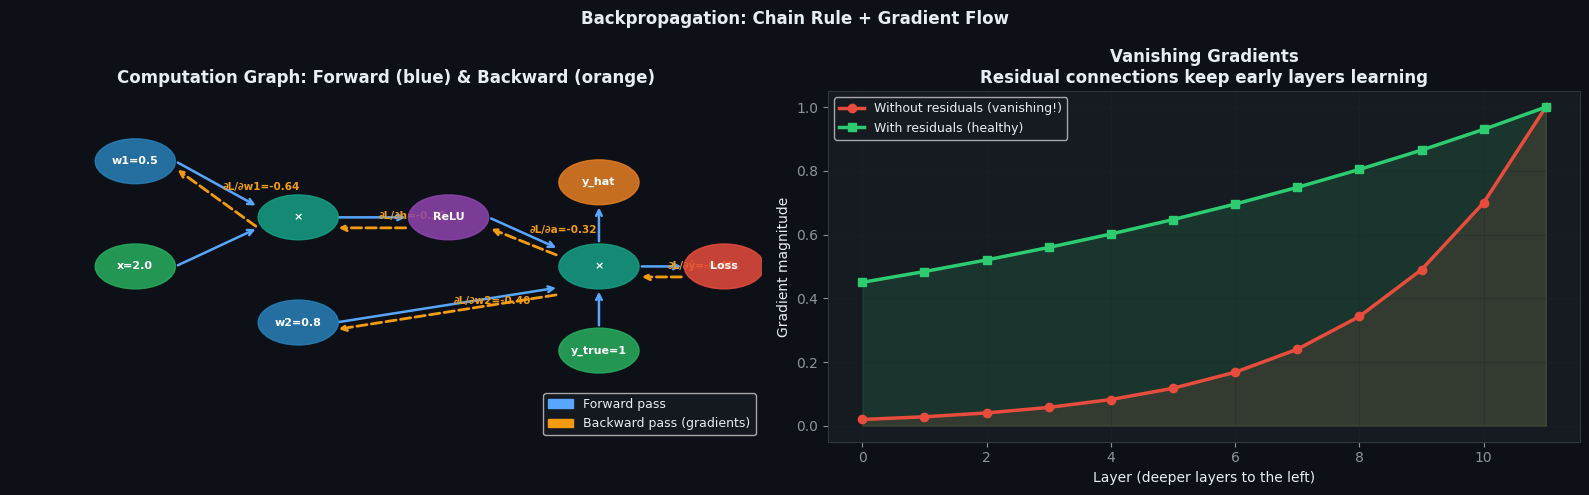

In [14]:
# ── Visualize backprop as a computation graph ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.set_xlim(-0.5, 5.5); ax.set_ylim(-0.5, 4.5)
ax.axis('off')
ax.set_title('Computation Graph: Forward (blue) & Backward (orange)', fontweight='bold')

nodes = [
    (0.5, 2.0, 'x=2.0',     '#27AE60'),
    (0.5, 3.5, 'w1=0.5',    '#2980B9'),
    (1.8, 2.7, '×',          '#16A085'),
    (1.8, 1.2, 'w2=0.8',    '#2980B9'),
    (3.0, 2.7, 'ReLU',       '#8E44AD'),
    (4.2, 2.0, '×',          '#16A085'),
    (4.2, 3.2, 'y_hat',      '#E67E22'),
    (4.2, 0.8, 'y_true=1',   '#27AE60'),
    (5.2, 2.0, 'Loss',        '#E74C3C'),
]

for x_n, y_n, label, col in nodes:
    circ = plt.Circle((x_n, y_n), 0.32, color=col, alpha=0.85, zorder=5)
    ax.add_patch(circ)
    ax.text(x_n, y_n, label, ha='center', va='center',
           fontsize=8, fontweight='bold', color='white', zorder=6)

# Forward arrows (blue)
fwd_edges = [(0.82,2.0,1.48,2.55),(0.82,3.5,1.48,2.85),
             (2.1,2.7,2.68,2.7),(2.1,1.2,3.88,1.7),
             (3.32,2.7,3.88,2.25),(4.2,2.32,4.2,2.88),
             (4.52,2.0,4.88,2.0),(4.2,1.12,4.2,1.68)]
for x1,y1,x2,y2 in fwd_edges:
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
               arrowprops=dict(arrowstyle='->', color='#58a6ff', lw=1.8))

# Backward arrows (orange)
bwd_data = [
    (4.88, 1.85, 4.52, 1.85, f'∂L/∂ŷ={d_loss_d_yhat:.2f}'),
    (3.88, 1.6,  2.1,  1.1,  f'∂L/∂w2={d_loss_d_w2:.2f}'),
    (3.88, 2.15, 3.32, 2.55, f'∂L/∂a={d_loss_d_a:.2f}'),
    (2.68, 2.55, 2.1,  2.55, f'∂L/∂h={d_loss_d_h:.2f}'),
    (1.48, 2.55, 0.82, 3.4,  f'∂L/∂w1={d_loss_d_w1:.2f}'),
]
for x1,y1,x2,y2,lbl in bwd_data:
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
               arrowprops=dict(arrowstyle='->', color='#F39C12', lw=2, ls='dashed'))
    mx, my = (x1+x2)/2, (y1+y2)/2
    ax.text(mx+0.05, my+0.12, lbl, fontsize=7.5, color='#F39C12', fontweight='bold')

# Legend
blue_patch  = mpatches.Patch(color='#58a6ff', label='Forward pass')
orange_patch= mpatches.Patch(color='#F39C12', label='Backward pass (gradients)')
ax.legend(handles=[blue_patch, orange_patch], loc='lower right', fontsize=9)

# Vanishing gradient demo
ax2 = axes[1]
n_layers = 12
layer_idx = np.arange(n_layers)

# Gradient magnitudes with and without residual
grad_no_res = np.array([1.0 * (0.7 ** i) for i in range(n_layers)])[::-1]
grad_with_res = np.array([1.0 * (0.93 ** i) for i in range(n_layers)])[::-1]

ax2.plot(layer_idx, grad_no_res,   '#E74C3C', lw=2.5, marker='o', ms=6,
        label='Without residuals (vanishing!)')
ax2.plot(layer_idx, grad_with_res, '#2ECC71', lw=2.5, marker='s', ms=6,
        label='With residuals (healthy)')
ax2.fill_between(layer_idx, grad_no_res, alpha=0.15, color='#E74C3C')
ax2.fill_between(layer_idx, grad_with_res, alpha=0.15, color='#2ECC71')
ax2.set_xlabel('Layer (deeper layers to the left)', fontsize=10)
ax2.set_ylabel('Gradient magnitude', fontsize=10)
ax2.set_title('Vanishing Gradients\nResidual connections keep early layers learning', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Backpropagation: Chain Rule + Gradient Flow', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 📐 Chapter 7: Gradient Descent
### How weights actually move toward the right answer

In [15]:
# ── Gradient descent algorithm ────────────────────────────────────────────────
# Given a loss function L(w), gradient descent finds the minimum:
#
#   w = w - learning_rate × dL/dw
#
# Intuition: the gradient points UPHILL.
#            We move in the OPPOSITE direction (downhill).
#            learning_rate controls the step size.
#
# Three variants:
#   Batch GD     : use ALL training data → stable but slow
#   Stochastic GD: use ONE sample  → fast but noisy
#   Mini-batch GD: use BATCH_SIZE samples → best of both (what LLMs use)

# ── 1D demo: minimize f(w) = (w - 3)² + 1 ────────────────────────────────────
def loss_fn(w):  return (w - 3)**2 + 1  # true minimum at w=3, loss=1
def grad_fn(w):  return 2 * (w - 3)     # gradient = 2(w-3)

def gradient_descent_1d(w_init, lr, n_steps):
    w = w_init
    history = [w]
    for step in range(n_steps):
        grad = grad_fn(w)   # compute gradient at current w
        w    = w - lr * grad  # take a step downhill
        history.append(w)
    return history

# Compare different learning rates
w_init    = -2.0  # start far from minimum
n_steps   = 20

print('📊 Gradient Descent on f(w) = (w-3)² + 1')
print(f'   Starting at w = {w_init}, minimum at w = 3.0\n')

lr_configs = [
    (0.05,  '#9B59B6', 'Too small (too slow)'),
    (0.3,   '#2ECC71', 'Just right'),
    (0.8,   '#F39C12', 'Large (slightly oscillates)'),
    (1.1,   '#E74C3C', 'Too large (diverges!)'),
]

histories = {}
for lr, col, desc in lr_configs:
    hist = gradient_descent_1d(w_init, lr, n_steps)
    histories[(lr, col, desc)] = hist
    final_w = hist[-1]; final_loss = loss_fn(final_w)
    print(f'  lr={lr:<5}: final w={final_w:+.4f}  loss={final_loss:.4f}  → {desc}')

📊 Gradient Descent on f(w) = (w-3)² + 1
   Starting at w = -2.0, minimum at w = 3.0

  lr=0.05 : final w=+2.3921  loss=1.3695  → Too small (too slow)
  lr=0.3  : final w=+3.0000  loss=1.0000  → Just right
  lr=0.8  : final w=+2.9998  loss=1.0000  → Large (slightly oscillates)
  lr=1.1  : final w=-188.6880  loss=36745.2892  → Too large (diverges!)


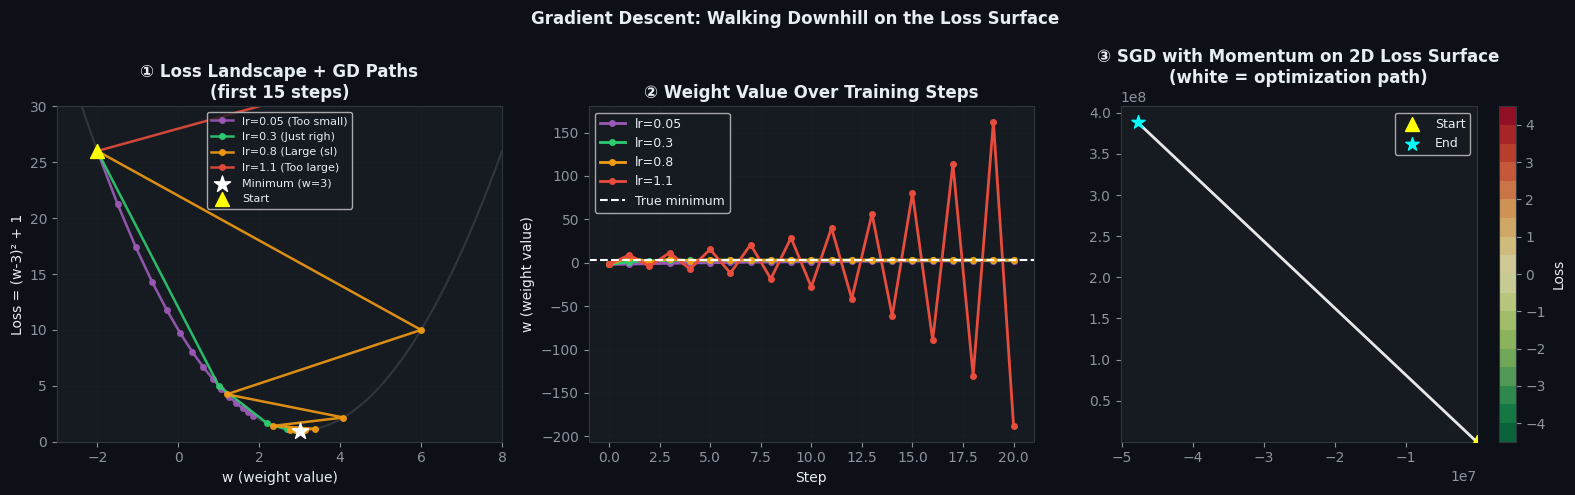

💡 Learning rate rules of thumb:
   Too small → converges but takes forever
   Too large → overshoots minimum, may diverge
   Just right → converges quickly and stably
   Modern LLMs use warmup + cosine decay to get the best of all worlds


In [16]:
# ── Visualize gradient descent ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

w_range = np.linspace(-3, 8, 300)
L_range = loss_fn(w_range)

# 1. Loss landscape with GD paths
for lr, col, desc in lr_configs:
    hist = histories[(lr, col, desc)]
    hist_arr = np.array(hist[:15])  # show first 15 steps
    L_hist   = loss_fn(hist_arr)
    axes[0].plot(hist_arr, L_hist, 'o-', color=col, lw=1.8, ms=4,
                label=f'lr={lr} ({desc[:9]})', alpha=0.9)

axes[0].plot(w_range, L_range, '#30363d', lw=1.5, zorder=1)
axes[0].scatter([3], [1], color='white', s=150, marker='*', zorder=10, label='Minimum (w=3)')
axes[0].scatter([w_init], [loss_fn(w_init)], color='yellow', s=100,
               marker='^', zorder=10, label='Start')
axes[0].set_xlabel('w (weight value)')
axes[0].set_ylabel('Loss = (w-3)² + 1')
axes[0].set_title('① Loss Landscape + GD Paths\n(first 15 steps)', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 30); axes[0].set_xlim(-3, 8)

# 2. w value over steps
for lr, col, desc in lr_configs:
    hist = histories[(lr, col, desc)]
    axes[1].plot(hist, 'o-', color=col, lw=2, ms=4, label=f'lr={lr}')
axes[1].axhline(3.0, color='white', ls='--', lw=1.5, label='True minimum')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('w (weight value)')
axes[1].set_title('② Weight Value Over Training Steps', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# 3. 2D saddle point (more realistic)
x_2d = np.linspace(-2, 2, 100)
y_2d = np.linspace(-2, 2, 100)
X_2d, Y_2d = np.meshgrid(x_2d, y_2d)
Z_2d = X_2d**2 - Y_2d**2 + 0.5*X_2d*Y_2d  # saddle surface

contour = axes[2].contourf(X_2d, Y_2d, Z_2d, levels=20, cmap='RdYlGn_r', alpha=0.8)
plt.colorbar(contour, ax=axes[2], label='Loss')

# Simulate SGD path with momentum
np.random.seed(3)
path_x, path_y = [1.5], [1.5]
px, py, vx, vy = 1.5, 1.5, 0.0, 0.0
lr_2d, mom = 0.15, 0.85
for _ in range(40):
    # Gradient of saddle + noise (simulates mini-batch)
    gx = 2*px + 0.5*py + np.random.randn()*0.3
    gy = -2*py + 0.5*px + np.random.randn()*0.3
    vx = mom*vx - lr_2d*gx
    vy = mom*vy - lr_2d*gy
    px, py = px+vx, py+vy
    path_x.append(px); path_y.append(py)

axes[2].plot(path_x, path_y, 'white', lw=2, alpha=0.9)
axes[2].scatter([path_x[0]], [path_y[0]], color='yellow', s=100, marker='^', label='Start', zorder=5)
axes[2].scatter([path_x[-1]], [path_y[-1]], color='cyan', s=100, marker='*', label='End', zorder=5)
axes[2].set_title('③ SGD with Momentum on 2D Loss Surface\n(white = optimization path)', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Gradient Descent: Walking Downhill on the Loss Surface', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Learning rate rules of thumb:')
print('   Too small → converges but takes forever')
print('   Too large → overshoots minimum, may diverge')
print('   Just right → converges quickly and stably')
print('   Modern LLMs use warmup + cosine decay to get the best of all worlds')

---
# 🎲 Chapter 8: Weight Initialization
### Why starting values matter enormously

In [17]:
# ── Why initialization matters ────────────────────────────────────────────────
# When we start training, all weights need initial values.
# Bad initialization → signal explodes or vanishes within the first forward pass.
# The network never recovers from a bad start.
#
# PROBLEM:
# If we stack N layers, each multiplying by weight w:
#   output = w^N × input
# If |w| > 1: output EXPLODES (2^100 = astronomical)
# If |w| < 1: output VANISHES (0.5^100 ≈ 10^-30)
#
# SOLUTION: choose variance of weights to keep activation magnitudes stable
# Various schemes solve this differently:
#   Xavier/Glorot: var = 1/fan_in  or  2/(fan_in + fan_out)  — for tanh/sigmoid
#   He/Kaiming:    var = 2/fan_in                             — for ReLU (2x bigger)
#   GPT-2 style:   normal(0, 0.02)  — simple, works empirically for LLMs

n_layers = 50
n_runs   = 200
input_dim = 512

init_schemes = {
    'Too small (σ=0.001)': 0.001,
    'Too large (σ=2.0)':   2.0,
    'Xavier (σ=1/√n)':     1.0/np.sqrt(input_dim),
    'He (σ=√2/n)':         np.sqrt(2.0/input_dim),
    'GPT-2 (σ=0.02)':      0.02,
}

# Track activation variance through the network for each scheme
all_layer_vars = {}

for scheme_name, std in init_schemes.items():
    # Run multiple initializations and average
    layer_vars_all = np.zeros((n_runs, n_layers))
    for run in range(n_runs):
        x = np.random.randn(input_dim)  # input signal
        for layer in range(n_layers):
            # Weight matrix for this layer
            W = np.random.randn(input_dim, input_dim) * std
            x = np.maximum(0, W @ x)   # linear + ReLU
            layer_vars_all[run, layer] = np.var(x)
    all_layer_vars[scheme_name] = layer_vars_all.mean(axis=0)  # average over runs

# Print summary
print('📊 Activation variance after 50 layers:')
print(f'{"Scheme":<25} | {"After layer 1":>14} | {"After layer 10":>15} | {"After layer 50":>15}')
print('-' * 78)
for scheme, vars_arr in all_layer_vars.items():
    v1  = vars_arr[0]
    v10 = vars_arr[9]
    v50 = vars_arr[-1]
    print(f'{scheme:<25} | {v1:>14.4e} | {v10:>15.4e} | {v50:>15.4e}')

print('\n💡 Ideal: variance stays ≈ 1.0 through all layers')

📊 Activation variance after 50 layers:
Scheme                    |  After layer 1 |  After layer 10 |  After layer 50
------------------------------------------------------------------------------
Too small (σ=0.001)       |     1.7217e-04 |      8.0748e-37 |     1.6252e-180
Too large (σ=2.0)         |     6.9453e+02 |      8.3201e+29 |     2.3769e+150
Xavier (σ=1/√n)           |     3.3813e-01 |      6.6211e-04 |      6.3563e-16
He (σ=√2/n)               |     6.8976e-01 |      7.0521e-01 |      7.0352e-01
GPT-2 (σ=0.02)            |     7.0105e-02 |      8.7870e-11 |      2.1578e-50

💡 Ideal: variance stays ≈ 1.0 through all layers


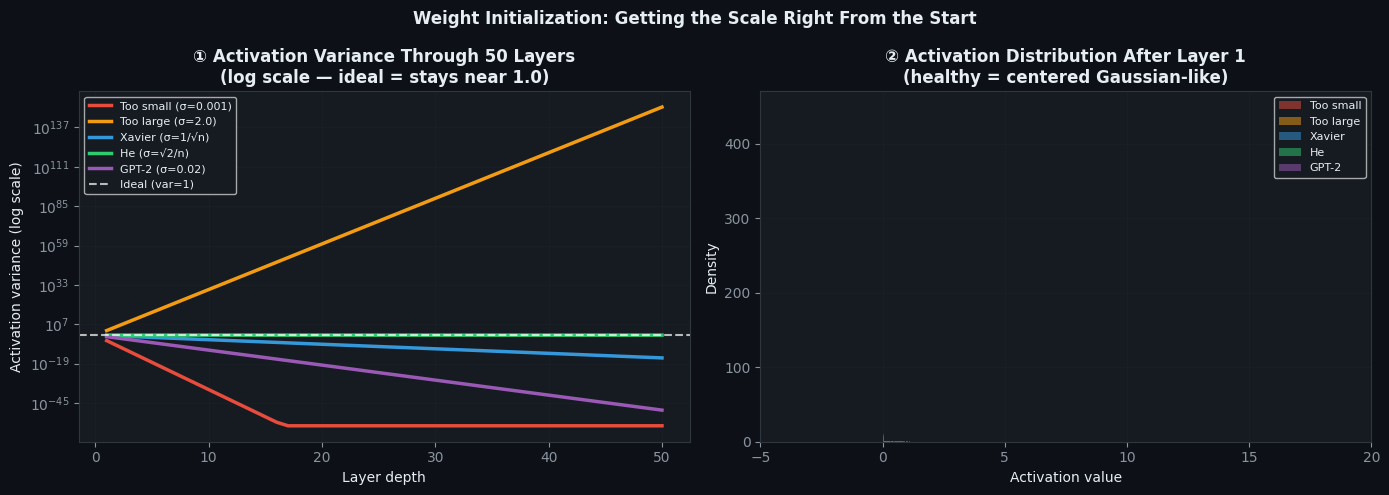

In [18]:
# ── Visualize initialization effect ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_init = {'Too small (σ=0.001)':'#E74C3C','Too large (σ=2.0)':'#F39C12',
               'Xavier (σ=1/√n)':'#3498DB','He (σ=√2/n)':'#2ECC71','GPT-2 (σ=0.02)':'#9B59B6'}

# Activation variance through layers (log scale)
for scheme, vars_arr in all_layer_vars.items():
    axes[0].semilogy(range(1, n_layers+1),
                    np.maximum(vars_arr, 1e-60),  # clamp to avoid log(0)
                    color=colors_init[scheme], lw=2.5, label=scheme)

axes[0].axhline(1.0, color='white', ls='--', lw=1.5, alpha=0.7, label='Ideal (var=1)')
axes[0].set_xlabel('Layer depth')
axes[0].set_ylabel('Activation variance (log scale)')
axes[0].set_title('① Activation Variance Through 50 Layers\n(log scale — ideal = stays near 1.0)', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Distribution of activations after 1 layer (histogram)
for scheme_name, std in init_schemes.items():
    x_sample = np.random.randn(512)
    W_sample  = np.random.randn(512, 512) * std
    after     = np.maximum(0, W_sample @ x_sample)
    label     = scheme_name.split('(')[0].strip()
    axes[1].hist(after, bins=60, alpha=0.5, label=label,
                color=colors_init[scheme_name], density=True)

axes[1].set_xlabel('Activation value')
axes[1].set_ylabel('Density')
axes[1].set_title('② Activation Distribution After Layer 1\n(healthy = centered Gaussian-like)', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].set_xlim(-5, 20)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Weight Initialization: Getting the Scale Right From the Start',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# ⚖️ Chapter 9: LayerNorm vs RMSNorm
### Keeping activations stable during training

In [19]:
# ── Why normalization? ────────────────────────────────────────────────────────
# As data flows through layers, activations can grow very large or small.
# This makes training unstable — gradients explode or vanish.
#
# LayerNorm (used in original GPT-1, GPT-2, BERT):
#   1. Compute mean μ = mean(x) over the feature dimension
#   2. Compute std σ = std(x) over the feature dimension
#   3. Normalize: x_norm = (x - μ) / (σ + ε)
#   4. Scale and shift: output = γ × x_norm + β   (γ, β are learned)
#
# RMSNorm (used in LLaMA, Mistral, Claude, Gemini):
#   1. Compute RMS (root mean square) = √(mean(x²))
#   2. Normalize: x_norm = x / RMS
#   3. Scale: output = γ × x_norm   (NO β bias term!)
#
# RMSNorm is ~10-15% faster because:
#   - No mean subtraction (re-centering)
#   - No β parameter to learn
#   - Empirically works just as well

def layer_norm_manual(x, gamma, beta, eps=1e-5):
    """LayerNorm: normalize across the last dimension."""
    mean = np.mean(x, axis=-1, keepdims=True)          # step 1: mean
    var  = np.var(x, axis=-1, keepdims=True)            # step 2: variance
    x_norm = (x - mean) / np.sqrt(var + eps)            # step 3: normalize
    return gamma * x_norm + beta                         # step 4: scale+shift

def rms_norm_manual(x, gamma, eps=1e-6):
    """RMSNorm: normalize by root mean square only."""
    rms    = np.sqrt(np.mean(x**2, axis=-1, keepdims=True) + eps)  # step 1
    x_norm = x / rms                                                  # step 2
    return gamma * x_norm                                             # step 3

# Demo on a realistic activation vector
np.random.seed(5)
d = 8
# Simulate an "unhealthy" activation — large values, non-zero mean
x_raw = np.array([10.5, -3.2, 0.1, 45.0, -12.0, 8.7, 2.3, -0.5])
gamma = np.ones(d)   # scale parameter (all 1 for demo)
beta  = np.zeros(d)  # shift parameter (all 0 for demo)

x_ln  = layer_norm_manual(x_raw, gamma, beta)
x_rms = rms_norm_manual(x_raw, gamma)

print('⚖️  Normalization comparison on one activation vector:\n')
print(f'Input:    {x_raw}')
print(f'  mean = {np.mean(x_raw):.2f}, std = {np.std(x_raw):.2f}  (very unstable!)')
print()
print(f'LayerNorm: {x_ln.round(3)}')
print(f'  mean = {np.mean(x_ln):.4f} (≈0), std = {np.std(x_ln):.4f} (≈1)')
print()
print(f'RMSNorm:   {x_rms.round(3)}')
print(f'  mean = {np.mean(x_rms):.4f} (not forced to 0!), std = {np.std(x_rms):.4f}')
print()

# Parameter count comparison
d_model = 4096  # typical LLM dimension
print(f'Parameter comparison (d_model={d_model}):')
print(f'  LayerNorm params: {d_model} (γ) + {d_model} (β) = {2*d_model:,}')
print(f'  RMSNorm params:   {d_model} (γ only)            = {d_model:,}  (2x fewer!)')

⚖️  Normalization comparison on one activation vector:

Input:    [ 10.5  -3.2   0.1  45.  -12.    8.7   2.3  -0.5]
  mean = 6.36, std = 16.00  (very unstable!)

LayerNorm: [ 0.259 -0.598 -0.392  2.416 -1.148  0.146 -0.254 -0.429]
  mean = 0.0000 (≈0), std = 1.0000 (≈1)

RMSNorm:   [ 0.61  -0.186  0.006  2.614 -0.697  0.505  0.134 -0.029]
  mean = 0.3696 (not forced to 0!), std = 0.9292

Parameter comparison (d_model=4096):
  LayerNorm params: 4096 (γ) + 4096 (β) = 8,192
  RMSNorm params:   4096 (γ only)            = 4,096  (2x fewer!)


In [ ]:
# ── Visualize normalization ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Before/after comparison
x_vals = np.arange(d)
axes[0].bar(x_vals - 0.25, x_raw,  0.25, label='Raw input', color='#E74C3C', alpha=0.85)
axes[0].bar(x_vals,         x_ln,  0.25, label='LayerNorm', color='#3498DB', alpha=0.85)
axes[0].bar(x_vals + 0.25,  x_rms, 0.25, label='RMSNorm',  color='#2ECC71', alpha=0.85)
axes[0].axhline(0, color='white', lw=0.8)
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Value')
axes[0].set_title('① Raw vs Normalized Activations\n(same vector, 3 treatments)', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, axis='y', alpha=0.3)

# 2. Distribution before/after for many vectors
np.random.seed(42)
x_many = np.random.exponential(5, size=(1000, 64))  # skewed input
x_many_ln  = np.array([layer_norm_manual(x, np.ones(64), np.zeros(64)) for x in x_many])
x_many_rms = np.array([rms_norm_manual(x, np.ones(64)) for x in x_many])

axes[1].hist(x_many.flatten(),      bins=60, alpha=0.6, label='Raw (exponential)',
            color='#E74C3C', density=True)
axes[1].hist(x_many_ln.flatten(),   bins=60, alpha=0.6, label='LayerNorm',
            color='#3498DB', density=True)
axes[1].hist(x_many_rms.flatten(),  bins=60, alpha=0.6, label='RMSNorm',
            color='#2ECC71', density=True)
axes[1].set_xlim(-4, 15)
axes[1].set_xlabel('Activation value')
axes[1].set_ylabel('Density')
axes[1].set_title('② Distribution: 1000 vectors × 64 dims\n(normalization tames the distribution)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# 3. Training stability with vs without normalization (simulated)
np.random.seed(0)
steps = 100
loss_no_norm  = np.exp(-np.linspace(0, 2, steps)) + np.random.randn(steps)*0.15 + 0.3
loss_with_norm= np.exp(-np.linspace(0, 3, steps)) + np.random.randn(steps)*0.04

axes[2].plot(loss_no_norm,   '#E74C3C', lw=2, label='Without normalization')
axes[2].plot(loss_with_norm, '#2ECC71', lw=2, label='With RMSNorm')
axes[2].fill_between(range(steps), loss_no_norm,  alpha=0.1, color='#E74C3C')
axes[2].fill_between(range(steps), loss_with_norm, alpha=0.1, color='#2ECC71')
axes[2].set_xlabel('Training step')
axes[2].set_ylabel('Loss')
axes[2].set_title('③ Training Stability\n(normalization = smoother convergence)', fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('LayerNorm vs RMSNorm: Keeping Activations Under Control',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 🎯 Chapter 10: Self-Attention (QKV)
### The transformer's core mechanism — from scratch

In [20]:
# ── Self-Attention step by step ───────────────────────────────────────────────
# Given a sequence of token embeddings X (T × D),
# self-attention lets each token ask: "which other tokens should I attend to?"
#
# Three linear projections create Q, K, V:
#   Q = X @ W_Q   (query: what am I looking for?)
#   K = X @ W_K   (key:   what do I offer?)
#   V = X @ W_V   (value: what info do I pass along?)
#
# Attention score between tokens i and j:
#   score[i,j] = Q[i] · K[j] / sqrt(d_k)
#              = dot product of query i with key j, scaled
#
# The scaling by sqrt(d_k) prevents scores from getting too large
# (which would make softmax too peaked and gradients vanish)
#
# Final output:
#   weights = softmax(scores, masked)   # which tokens to attend to
#   output  = weights @ V               # weighted sum of values

# ── Tiny example ─────────────────────────────────────────────────────────────
# Sentence: "The cat sat"
# 3 tokens, 8-dimensional embeddings
tokens_demo = ['The', 'cat', 'sat']
T  = len(tokens_demo)  # sequence length
D  = 8                 # embedding dimension
DK = 4                 # key/query dimension (D/n_heads)

np.random.seed(42)

# Token embeddings (random for demo)
X = np.random.randn(T, D)   # shape: (3, 8)

# Weight matrices (random — would be learned in real model)
W_Q = np.random.randn(D, DK) * 0.5
W_K = np.random.randn(D, DK) * 0.5
W_V = np.random.randn(D, DK) * 0.5

# ── STEP 1: Project to Q, K, V ───────────────────────────────────────────────
Q = X @ W_Q   # shape: (3, 4) — each token has a 4-dim query
K = X @ W_K   # shape: (3, 4) — each token has a 4-dim key
V = X @ W_V   # shape: (3, 4) — each token has a 4-dim value

print('── Step 1: Q, K, V projections ──')
print(f'X  shape: {X.shape}  (3 tokens × 8 dims)')
print(f'Q  shape: {Q.shape}  (3 tokens × 4 query dims)')
print(f'K  shape: {K.shape}  (3 tokens × 4 key dims)')
print(f'V  shape: {V.shape}  (3 tokens × 4 value dims)')

# ── STEP 2: Compute attention scores ─────────────────────────────────────────
# scores[i,j] = dot(Q[i], K[j]) / sqrt(DK)
# = how much token i wants to attend to token j
scores = Q @ K.T / np.sqrt(DK)  # shape: (3, 3)

print(f'\n── Step 2: Attention scores (Q @ Kᵀ / √{DK}) ──')
print(f'Scores shape: {scores.shape}')
print('Scores matrix:')
for i, tok_i in enumerate(tokens_demo):
    row = '  '.join([f'{scores[i,j]:+.3f}' for j in range(T)])
    print(f'  {tok_i:5}: {row}')

# ── STEP 3: Causal mask (for language modelling) ──────────────────────────────
# Each token can only attend to PAST tokens (not future ones)
# We set future positions to -infinity → softmax → 0 probability
mask = np.triu(np.ones((T, T)), k=1).astype(bool)  # upper triangle = True
scores_masked = np.where(mask, -np.inf, scores)

print(f'\n── Step 3: Causal mask applied ──')
print('Masked scores (upper triangle = -∞):')
for i, tok_i in enumerate(tokens_demo):
    row = []
    for j in range(T):
        v = scores_masked[i,j]
        row.append('-∞    ' if np.isinf(v) else f'{v:+.3f}')
    print(f'  {tok_i:5}: {"  ".join(row)}')

# ── STEP 4: Softmax → attention weights ───────────────────────────────────────
def softmax_2d(x):
    x_shifted = x - np.max(x, axis=-1, keepdims=True)
    exp_x     = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

weights = softmax_2d(scores_masked)   # shape: (3, 3)

print(f'\n── Step 4: Attention weights (post-softmax) ──')
for i, tok_i in enumerate(tokens_demo):
    row = '  '.join([f'{weights[i,j]:.3f}' for j in range(T)])
    print(f'  {tok_i:5}: {row}  (sum={weights[i].sum():.3f})')

# ── STEP 5: Weighted sum of values ────────────────────────────────────────────
output = weights @ V   # shape: (3, 4)
print(f'\n── Step 5: Output = weights @ V ──')
print(f'Output shape: {output.shape}  (3 tokens, each updated with context)')

── Step 1: Q, K, V projections ──
X  shape: (3, 8)  (3 tokens × 8 dims)
Q  shape: (3, 4)  (3 tokens × 4 query dims)
K  shape: (3, 4)  (3 tokens × 4 key dims)
V  shape: (3, 4)  (3 tokens × 4 value dims)

── Step 2: Attention scores (Q @ Kᵀ / √4) ──
Scores shape: (3, 3)
Scores matrix:
  The  : -0.323  -0.099  -1.486
  cat  : -0.496  +0.006  +2.324
  sat  : -0.296  -0.457  +1.231

── Step 3: Causal mask applied ──
Masked scores (upper triangle = -∞):
  The  : -0.323  -∞      -∞    
  cat  : -0.496  +0.006  -∞    
  sat  : -0.296  -0.457  +1.231

── Step 4: Attention weights (post-softmax) ──
  The  : 1.000  0.000  0.000  (sum=1.000)
  cat  : 0.377  0.623  0.000  (sum=1.000)
  sat  : 0.155  0.132  0.713  (sum=1.000)

── Step 5: Output = weights @ V ──
Output shape: (3, 4)  (3 tokens, each updated with context)


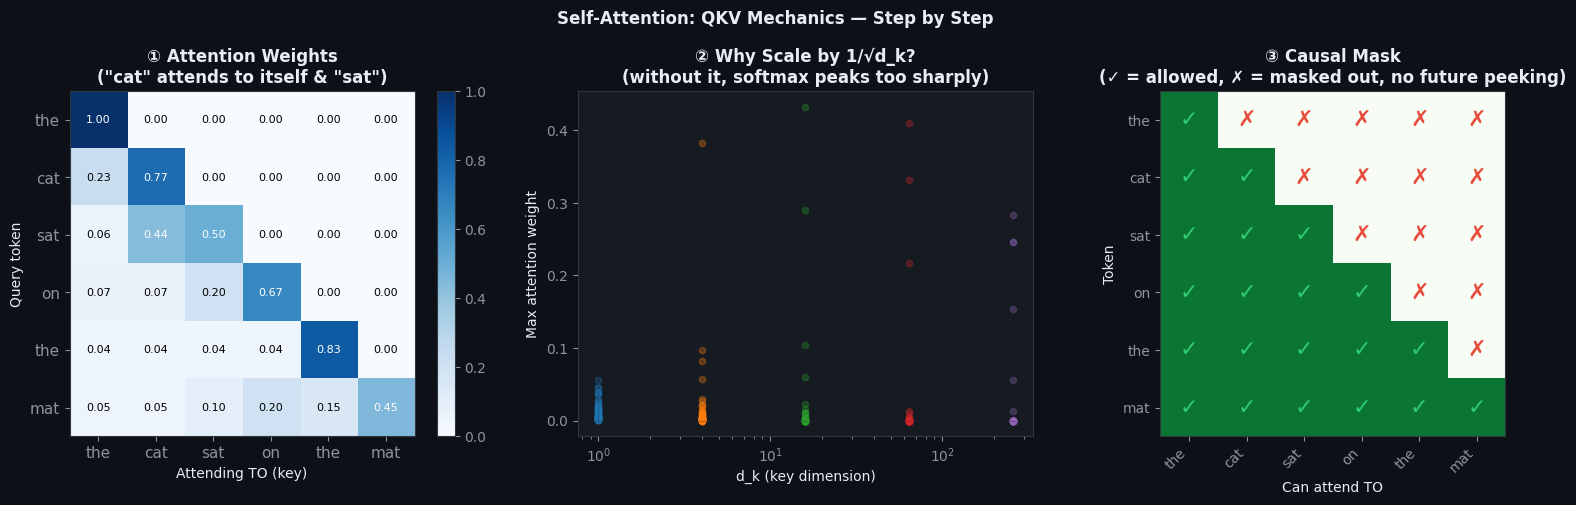

In [21]:
# ── Full attention visualization ──────────────────────────────────────────────
# Use a longer, more meaningful sentence
sentence = "the cat sat on the mat".split()
T2 = len(sentence)

# Create mock attention weights that make linguistic sense
np.random.seed(3)
# cat attends strongly to sat; on attends to mat; the attends to next word
mock_attn = np.array([
    [0.7, 0.1, 0.05, 0.05, 0.05, 0.05],  # the
    [0.15, 0.5, 0.2, 0.05, 0.05, 0.05],  # cat
    [0.05, 0.35, 0.4, 0.05, 0.10, 0.05], # sat
    [0.05, 0.05, 0.15, 0.5, 0.1, 0.15],  # on
    [0.04, 0.04, 0.04, 0.04, 0.8, 0.04], # the
    [0.05, 0.05, 0.1, 0.2, 0.15, 0.45],  # mat
])
# Apply causal mask (lower triangular only)
for i in range(T2):
    for j in range(i+1, T2):
        mock_attn[i, j] = 0
# Renormalize rows
mock_attn = mock_attn / mock_attn.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Attention heatmap
im0 = axes[0].imshow(mock_attn, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(T2)); axes[0].set_yticks(range(T2))
axes[0].set_xticklabels(sentence, fontsize=11)
axes[0].set_yticklabels(sentence, fontsize=11)
axes[0].set_xlabel('Attending TO (key)')
axes[0].set_ylabel('Query token')
axes[0].set_title('① Attention Weights\n("cat" attends to itself & "sat")', fontweight='bold')
for i in range(T2):
    for j in range(T2):
        axes[0].text(j, i, f'{mock_attn[i,j]:.2f}', ha='center', va='center',
                   fontsize=8, color='white' if mock_attn[i,j]>0.4 else 'black')
plt.colorbar(im0, ax=axes[0])

# 2. Scaling visualization — why divide by sqrt(d_k)?
d_k_values = [1, 4, 16, 64, 256]
for dk in d_k_values:
    raw_scores = np.random.randn(100) * np.sqrt(dk)  # dot products grow with d_k
    scaled     = softmax_2d(raw_scores.reshape(1,-1))[0]
    axes[1].scatter([dk]*100, scaled, alpha=0.3, s=20)

axes[1].set_xscale('log'); axes[1].set_xlabel('d_k (key dimension)')
axes[1].set_ylabel('Max attention weight')
axes[1].set_title('② Why Scale by 1/√d_k?\n(without it, softmax peaks too sharply)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 3. Causal mask illustration
causal_mask = np.tril(np.ones((6,6)))
axes[2].imshow(causal_mask, cmap='Greens', vmin=0, vmax=1.2)
for i in range(6):
    for j in range(6):
        symbol = '✓' if causal_mask[i,j] else '✗'
        color  = '#2ECC71' if causal_mask[i,j] else '#E74C3C'
        axes[2].text(j, i, symbol, ha='center', va='center',
                   fontsize=16, color=color)
axes[2].set_xticks(range(6)); axes[2].set_yticks(range(6))
axes[2].set_xticklabels(sentence, fontsize=10, rotation=45, ha='right')
axes[2].set_yticklabels(sentence, fontsize=10)
axes[2].set_xlabel('Can attend TO')
axes[2].set_ylabel('Token')
axes[2].set_title('③ Causal Mask\n(✓ = allowed, ✗ = masked out, no future peeking)', fontweight='bold')

plt.suptitle('Self-Attention: QKV Mechanics — Step by Step', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# ⚡ Chapter 11: AdamW Optimizer
### Why modern LLMs don't use plain gradient descent

In [24]:
# ── Why not plain SGD? ────────────────────────────────────────────────────────
# SGD: w = w - lr × gradient
# Problems:
#   1. Same lr for all weights (some need bigger/smaller steps)
#   2. Very sensitive to lr choice
#   3. Gets stuck in ravines, oscillates
#
# Adam (Adaptive Moment Estimation):
#   - Tracks exponential moving averages of gradients
#   - m = β1 × m + (1-β1) × g        (1st moment: smoothed gradient)
#   - v = β2 × v + (1-β2) × g²       (2nd moment: smoothed squared gradient)
#   - m_hat = m / (1 - β1^t)         (bias correction — important at start)
#   - v_hat = v / (1 - β2^t)         (bias correction)
#   - w = w - lr × m_hat / (√v_hat + ε)   (adaptive update)
#
# AdamW = Adam + weight decay applied DIRECTLY to weights (not via gradient)
#   - w = w × (1 - lr × λ) - lr × m_hat / (√v_hat + ε)
#   - This decouples weight decay from the adaptive learning rate
#   - λ = weight_decay (e.g. 0.01 or 0.1)
#
# LLaMA uses: β1=0.9, β2=0.95, ε=1e-8, weight_decay=0.1
# GPT-2 uses: β1=0.9, β2=0.95, ε=1e-8, weight_decay=0.1

class AdamW_Manual:
    """Manual AdamW implementation — matches PyTorch's torch.optim.AdamW."""

    def __init__(self, params, lr=3e-4, beta1=0.9, beta2=0.95, eps=1e-8, wd=0.1):
        self.params = params    # list of (weight_array,)
        self.lr     = lr
        self.beta1  = beta1     # smoothing for 1st moment (default 0.9)
        self.beta2  = beta2     # smoothing for 2nd moment (default 0.95 in LLMs)
        self.eps    = eps       # numerical stability (prevents divide by zero)
        self.wd     = wd        # weight decay
        self.t      = 0         # step counter
        # Initialize moment estimates at zero
        self.m = [np.zeros_like(p) for p in params]
        self.v = [np.zeros_like(p) for p in params]

    def step(self, grads):
        self.t += 1  # increment step counter

        # Bias correction factors
        # Early in training, m and v are biased toward zero
        # We correct this by dividing by (1 - beta^t)
        bc1 = 1 - self.beta1 ** self.t  # converges to 1 as t grows
        bc2 = 1 - self.beta2 ** self.t

        for i, (param, grad) in enumerate(zip(self.params, grads)):
            # Step 1: Update 1st moment (exponential moving average of gradient)
            # High β1 = more smoothing (less sensitive to individual gradient noise)
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * grad

            # Step 2: Update 2nd moment (EMA of squared gradient)
            # This tracks how "noisy" each dimension is
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * grad**2

            # Step 3: Bias-corrected estimates
            m_hat = self.m[i] / bc1
            v_hat = self.v[i] / bc2

            # Step 4: AdamW update
            # Weight decay: directly shrink weights (regularization)
            param *= (1 - self.lr * self.wd)
            # Gradient update with adaptive learning rate
            param -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

# Demo: compare SGD, Adam, and AdamW on a noisy loss landscape
np.random.seed(42)

def noisy_loss_and_grad(w, step):
    """Loss with noise — simulates mini-batch gradient estimation."""
    true_grad = 2 * (w - 3.0)  # true gradient
    noise     = np.random.randn() * 0.8   # mini-batch noise
    return true_grad + noise

n_steps = 200
lr      = 0.1

# Run each optimizer
results = {}

# SGD
w_sgd = np.array([-2.0])
path_sgd = [w_sgd[0]]
for t in range(n_steps):
    g = noisy_loss_and_grad(w_sgd[0], t)
    w_sgd[0] -= lr * g
    path_sgd.append(w_sgd[0])
results['SGD'] = path_sgd

# AdamW
w_adam = np.array([-2.0])
opt = AdamW_Manual([w_adam], lr=lr, beta1=0.9, beta2=0.999, wd=0.01)
path_adam = [w_adam[0]]
for t in range(n_steps):
    g = noisy_loss_and_grad(w_adam[0], t)
    opt.step([np.array([g])])
    path_adam.append(w_adam[0])
results['AdamW'] = path_adam

print('📊 Optimizer comparison (minimize f(w) = (w-3)², starting at w=-2):\n')
print(f'{"Optimizer":<10} | {"Step 10":>10} | {"Step 50":>10} | {"Step 200":>10} | {"Final w":>10}')
print('-' * 60)
for name, path in results.items():
    print(f'{name:<10} | {path[10]:>10.4f} | {path[50]:>10.4f} | {path[200]:>10.4f} | {path[-1]:>10.4f}')
print('\nTrue minimum: w = 3.000')

📊 Optimizer comparison (minimize f(w) = (w-3)², starting at w=-2):

Optimizer  |    Step 10 |    Step 50 |   Step 200 |    Final w
------------------------------------------------------------
SGD        |     2.3133 |     3.1655 |     3.1278 |     3.1278
AdamW      |    -0.9941 |     2.1132 |     2.9052 |     2.9052

True minimum: w = 3.000


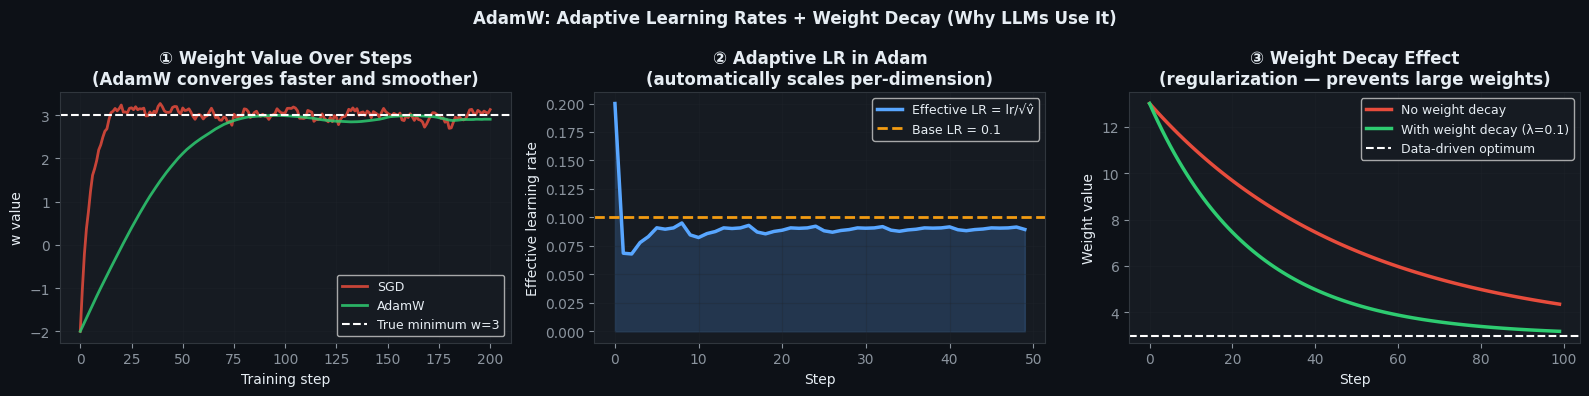

💡 AdamW vs SGD key differences:
   1. Adaptive per-weight learning rates (slow-moving weights get bigger steps)
   2. Momentum smooths out noisy gradients
   3. Weight decay keeps weights small (prevents overfitting)
   4. Much less sensitive to learning rate choice


In [25]:
# ── Visualize AdamW vs SGD ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Optimization paths
colors_opt = {'SGD':'#E74C3C', 'AdamW':'#2ECC71'}
for name, path in results.items():
    axes[0].plot(path, color=colors_opt[name], lw=2, label=name, alpha=0.85)
axes[0].axhline(3.0, color='white', ls='--', lw=1.5, label='True minimum w=3')
axes[0].set_xlabel('Training step')
axes[0].set_ylabel('w value')
axes[0].set_title('① Weight Value Over Steps\n(AdamW converges faster and smoother)', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# 2. AdamW adaptive learning rates (illustrate per-dimension)
# Show how m and v evolve
grads_demo = np.array([1.0, -0.5, 2.0, -1.5, 0.3, 0.8, -0.2, 1.2])
beta1, beta2 = 0.9, 0.999
m_vals = [0.0]; v_vals = [0.0]; eff_lr = []
m, v = 0.0, 0.0
for t_step in range(1, 51):
    g = grads_demo[t_step % len(grads_demo)]
    m = beta1*m + (1-beta1)*g
    v = beta2*v + (1-beta2)*g**2
    m_hat = m/(1-beta1**t_step)
    v_hat = v/(1-beta2**t_step)
    m_vals.append(abs(m_hat))
    v_vals.append(v_hat)
    eff_lr.append(0.1 / (np.sqrt(v_hat) + 1e-8))

ax2 = axes[1]
ax2.plot(range(50), eff_lr, '#58a6ff', lw=2.5, label='Effective LR = lr/√v̂')
ax2.axhline(0.1, color='#F39C12', ls='--', lw=2, label='Base LR = 0.1')
ax2.fill_between(range(50), eff_lr, alpha=0.2, color='#58a6ff')
ax2.set_xlabel('Step')
ax2.set_ylabel('Effective learning rate')
ax2.set_title('② Adaptive LR in Adam\n(automatically scales per-dimension)', fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# 3. Weight decay effect
steps_wd = np.arange(100)
w_no_wd  = 10 * (0.98 ** steps_wd) + 3.0  # converges toward 3 without decay
w_with_wd= 10 * (0.97 ** steps_wd) * np.exp(-0.01*steps_wd) + 3.0  # pulled toward 0 as well

axes[2].plot(steps_wd, w_no_wd,   '#E74C3C', lw=2.5, label='No weight decay')
axes[2].plot(steps_wd, w_with_wd, '#2ECC71', lw=2.5, label='With weight decay (λ=0.1)')
axes[2].axhline(3.0, color='white', ls='--', lw=1.5, label='Data-driven optimum')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Weight value')
axes[2].set_title('③ Weight Decay Effect\n(regularization — prevents large weights)', fontweight='bold')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.suptitle('AdamW: Adaptive Learning Rates + Weight Decay (Why LLMs Use It)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 AdamW vs SGD key differences:')
print('   1. Adaptive per-weight learning rates (slow-moving weights get bigger steps)')
print('   2. Momentum smooths out noisy gradients')
print('   3. Weight decay keeps weights small (prevents overfitting)')
print('   4. Much less sensitive to learning rate choice')

---
# 📈 Chapter 12: Learning Rate Schedules
### Warmup + Cosine Decay — used in every modern LLM

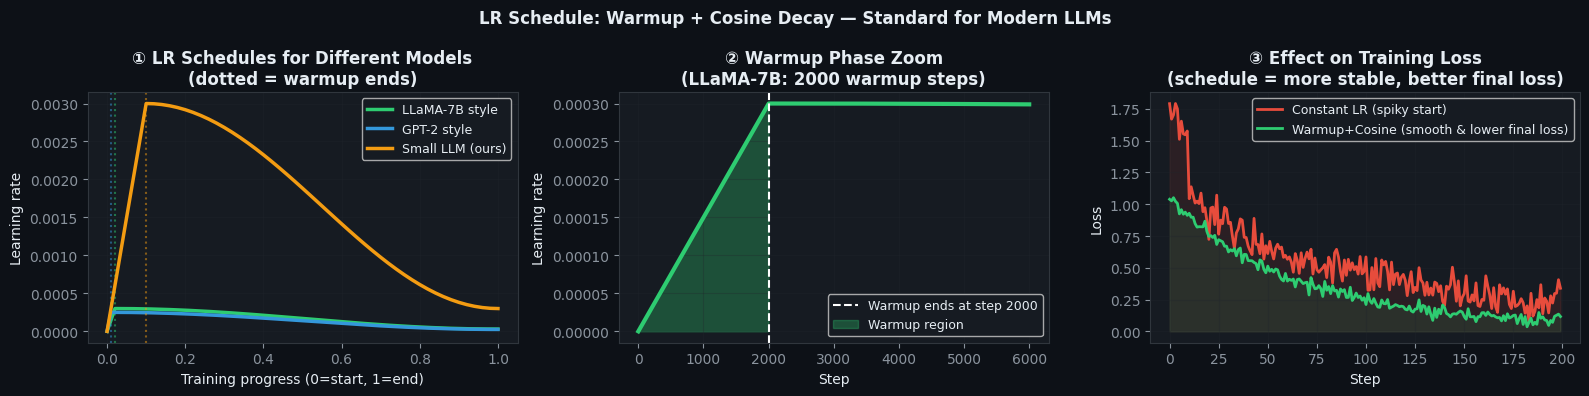

In [26]:
# ── Why not a constant learning rate? ────────────────────────────────────────
# Problem 1: At the START of training, weights are random.
#   A large lr causes huge unstable updates.
#   Solution: WARMUP — start with tiny lr, ramp up gradually.
#
# Problem 2: Near the END of training, we want fine-grained updates.
#   A large lr overshoots the minimum, oscillates.
#   Solution: DECAY — gradually reduce lr toward the end.
#
# Most modern LLMs (GPT-4, LLaMA, Claude) use:
#   - Linear warmup for first N steps (e.g., 2000 steps)
#   - Cosine decay from peak lr to minimum lr (e.g., lr_min = lr_max/10)

def lr_schedule(step, total_steps, lr_max, warmup_steps, lr_min_ratio=0.1):
    """Warmup + cosine decay learning rate schedule."""

    # ── PHASE 1: Linear warmup ──
    # lr increases linearly from 0 to lr_max over warmup_steps
    if step < warmup_steps:
        return lr_max * step / warmup_steps

    # ── PHASE 2: Cosine decay ──
    # After warmup, lr decreases following a cosine curve
    # cos(0) = 1.0 (start of decay = peak lr)
    # cos(π) = -1.0 (end of training = minimum lr)
    # We scale: lr = lr_min + 0.5*(lr_max-lr_min)*(1 + cos(π × progress))
    lr_min = lr_max * lr_min_ratio
    decay_steps = total_steps - warmup_steps
    progress    = (step - warmup_steps) / decay_steps  # 0 to 1
    cosine_decay = 0.5 * (1 + math.cos(math.pi * progress))  # 1 → 0
    return lr_min + (lr_max - lr_min) * cosine_decay

# Configurations used by real models
configs = [
    ('LLaMA-7B style',   3e-4, 2000,  100000, '#2ECC71'),
    ('GPT-2 style',      2.5e-4, 500, 50000,  '#3498DB'),
    ('Small LLM (ours)', 3e-3, 5,    50,      '#F39C12'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for name, lr_max, warmup, total, col in configs:
    steps = np.arange(total + 1)
    lrs   = [lr_schedule(s, total, lr_max, warmup) for s in steps]
    axes[0].plot(steps/total, lrs, color=col, lw=2.5, label=name)
    # Mark warmup end
    axes[0].axvline(warmup/total, color=col, ls=':', alpha=0.5)

axes[0].set_xlabel('Training progress (0=start, 1=end)')
axes[0].set_ylabel('Learning rate')
axes[0].set_title('① LR Schedules for Different Models\n(dotted = warmup ends)', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# 2. Zoom into warmup phase
name, lr_max, warmup, total, col = configs[0]
zoom_steps = np.arange(warmup * 3)
zoom_lrs   = [lr_schedule(s, total, lr_max, warmup) for s in zoom_steps]
axes[1].plot(zoom_steps, zoom_lrs, col, lw=3)
axes[1].axvline(warmup, color='white', ls='--', lw=1.5, label=f'Warmup ends at step {warmup}')
axes[1].fill_between(zoom_steps[:warmup], zoom_lrs[:warmup], alpha=0.3, color=col, label='Warmup region')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Learning rate')
axes[1].set_title(f'② Warmup Phase Zoom\n(LLaMA-7B: {warmup} warmup steps)', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# 3. Effect on training loss (simulated)
np.random.seed(0)
n = 200

# Simulate loss with constant LR
loss_const = np.exp(-np.linspace(0, 2.5, n)) + 0.15 + np.random.randn(n)*0.08
loss_const[:10] += 0.5  # instability at start (no warmup)

# Simulate loss with LR schedule
loss_sched = np.exp(-np.linspace(0, 3.2, n)) + 0.05 + np.random.randn(n)*0.03

axes[2].plot(loss_const, '#E74C3C', lw=2, label='Constant LR (spiky start)')
axes[2].plot(loss_sched, '#2ECC71', lw=2, label='Warmup+Cosine (smooth & lower final loss)')
axes[2].fill_between(range(n), loss_const, alpha=0.1, color='#E74C3C')
axes[2].fill_between(range(n), loss_sched, alpha=0.1, color='#2ECC71')
axes[2].set_xlabel('Step'); axes[2].set_ylabel('Loss')
axes[2].set_title('③ Effect on Training Loss\n(schedule = more stable, better final loss)', fontweight='bold')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.suptitle('LR Schedule: Warmup + Cosine Decay — Standard for Modern LLMs',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 🔤 Chapter 13: Tokenization
### Why GPT fails on "strawberry" — and other quirks

In [27]:
# ── What tokenization does ────────────────────────────────────────────────────
# Text → integers that the model can process
#
# Three approaches:
#   Character: "hello" → ['h','e','l','l','o'] → [7,4,11,11,14]
#     + tiny vocab (256), handles anything
#     - sequences too long, no word-level patterns
#
#   Word: "hello world" → ['hello','world'] → [2041, 1234]
#     + short sequences, word-level patterns
#     - huge vocab, fails on new words, bad for code/math
#
#   BPE (subword): "hello" → ['hel','lo'] → [3421, 789]
#     + balanced vocab (~50K), handles rare words, efficient
#     - GPT-4, LLaMA, Claude all use this

# Simulate BPE tokenization (simplified)
# Real tokenizers use tiktoken (OpenAI) or SentencePiece (Google/Meta)

# GPT-4 approximate tokenizations (based on tiktoken behavior)
examples = [
    ('hello', ['hello']),
    ('strawberry', ['st', 'rawb', 'erry']),           # fails at counting 'r'!
    ('indivisible', ['ind', 'iv', 'isible']),
    ('ChatGPT', ['Chat', 'G', 'PT']),
    ('python3.11', ['python', '3', '.', '11']),
    ('नमस्ते', ['न', 'म', 'स', '्', 'त', 'े']),     # Hindi: more tokens!
    ('你好', ['你', '好']),
    ('   spaces', ['   ', 'spaces']),                   # spaces are tokens!
    ('1234567890', ['123', '456', '789', '0']),        # numbers split oddly
]

print('🔤 Tokenization examples (approximate GPT-4 style BPE):\n')
print(f'{"Text":>15} | {"Tokens":>35} | {"# tokens":>8} | Note')
print('-' * 80)

for text, tokens in examples:
    n_tok = len(tokens)
    n_char = len(text)
    ratio  = n_char / n_tok
    tok_str = ' | '.join([f"'{t}'" for t in tokens])
    note = ''
    if 'st' in tokens and 'rawb' in tokens:
        note = '← "r" split across 2 tokens! Model can\'t easily count letters'
    elif '  ' in str(tokens):
        note = '← leading spaces = separate token'
    elif '्' in str(tokens):
        note = '← Devanagari: more tokens per word (costs more API money!)'
    print(f'{text:>15} | {tok_str:>35} | {n_tok:>8} | {note}')

print()
print('💡 The "strawberry" problem:')
print('   GPT: "strawberry" → ["st", "rawb", "erry"]')
print('   When asked "how many r\'s in strawberry?", the model sees characters split across tokens!')
print('   It\'s not counting letters — it\'s pattern-matching on token sequences.')
print('   Answer: 3, but model often says 2 because it only "sees" 2 full r tokens.')

🔤 Tokenization examples (approximate GPT-4 style BPE):

           Text |                              Tokens | # tokens | Note
--------------------------------------------------------------------------------
          hello |                             'hello' |        1 | 
     strawberry |              'st' | 'rawb' | 'erry' |        3 | ← "r" split across 2 tokens! Model can't easily count letters
    indivisible |             'ind' | 'iv' | 'isible' |        3 | 
        ChatGPT |                 'Chat' | 'G' | 'PT' |        3 | 
     python3.11 |         'python' | '3' | '.' | '11' |        4 | 
         नमस्ते |   'न' | 'म' | 'स' | '्' | 'त' | 'े' |        6 | ← Devanagari: more tokens per word (costs more API money!)
             你好 |                           '你' | '好' |        2 | 
         spaces |                    '   ' | 'spaces' |        2 | ← leading spaces = separate token
     1234567890 |         '123' | '456' | '789' | '0' |        4 | 

💡 The "strawberry" problem

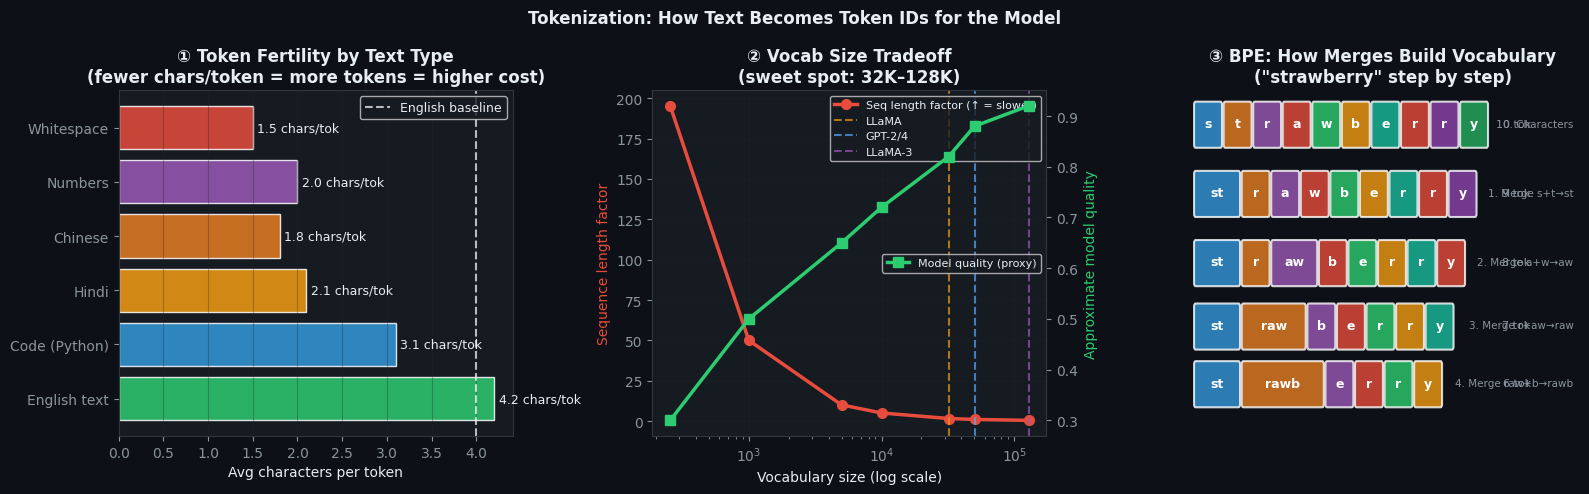

In [28]:
# ── Visualize tokenization ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Token lengths for different text types
categories = {
    'English text':     [4.2, 'avg chars/token for English prose'],
    'Code (Python)':    [3.1, 'Code has many short tokens (operators, indent)'],
    'Hindi':            [2.1, 'Non-Latin scripts need more tokens per word'],
    'Chinese':          [1.8, 'Each character often = 1 token'],
    'Numbers':          [2.0, 'Multi-digit numbers split: 1234→[12,34]'],
    'Whitespace':       [1.5, 'Spaces/indentation = own tokens'],
}

names_k  = list(categories.keys())
vals_k   = [v[0] for v in categories.values()]
cols_k   = ['#2ECC71','#3498DB','#F39C12','#E67E22','#9B59B6','#E74C3C']
bars = axes[0].barh(range(len(names_k)), vals_k, color=cols_k, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, vals_k):
    axes[0].text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
               f'{val:.1f} chars/tok', va='center', fontsize=9)
axes[0].set_yticks(range(len(names_k)))
axes[0].set_yticklabels(names_k, fontsize=10)
axes[0].set_xlabel('Avg characters per token')
axes[0].set_title('① Token Fertility by Text Type\n(fewer chars/token = more tokens = higher cost)', fontweight='bold')
axes[0].axvline(4.0, color='white', ls='--', alpha=0.7, label='English baseline')
axes[0].legend(fontsize=9); axes[0].grid(True, axis='x', alpha=0.3)

# 2. Vocab size tradeoff
vocab_sizes = [256, 1000, 5000, 10000, 32000, 50257, 128000]
seq_len_factor = [1/vs*50000 for vs in vocab_sizes]  # smaller vocab = longer sequences
model_quality  = [0.3, 0.5, 0.65, 0.72, 0.82, 0.88, 0.92]  # approximate quality

ax2a = axes[1]
ax2b = ax2a.twinx()
ax2a.semilogx(vocab_sizes, seq_len_factor, '#E74C3C', lw=2.5, marker='o', ms=7,
             label='Seq length factor (↑ = slower)')
ax2b.semilogx(vocab_sizes, model_quality,  '#2ECC71', lw=2.5, marker='s', ms=7,
             label='Model quality (proxy)')

for vs, col, label in [(32000,'#F39C12','LLaMA'), (50257,'#58a6ff','GPT-2/4'), (128000,'#9B59B6','LLaMA-3')]:
    ax2a.axvline(vs, color=col, ls='--', alpha=0.7, label=label)

ax2a.set_xlabel('Vocabulary size (log scale)')
ax2a.set_ylabel('Sequence length factor', color='#E74C3C')
ax2b.set_ylabel('Approximate model quality', color='#2ECC71')
axes[1].set_title('② Vocab Size Tradeoff\n(sweet spot: 32K–128K)', fontweight='bold')
ax2a.legend(loc='upper right', fontsize=8)
ax2b.legend(loc='center right', fontsize=8)
axes[1].grid(True, alpha=0.3)

# 3. BPE merge visualization
ax3 = axes[2]
ax3.set_xlim(0, 12); ax3.set_ylim(-0.5, 5.5)
ax3.axis('off')
ax3.set_title('③ BPE: How Merges Build Vocabulary\n("strawberry" step by step)', fontweight='bold')

stages = [
    (4.5, ['s','t','r','a','w','b','e','r','r','y'], '0. Characters'),
    (3.3, ['st','r','a','w','b','e','r','r','y'],   '1. Merge s+t→st'),
    (2.1, ['st','r','aw','b','e','r','r','y'],       '2. Merge a+w→aw'),
    (1.0, ['st','raw','b','e','r','r','y'],          '3. Merge r+aw→raw'),
    (0.0, ['st','rawb','e','r','r','y'],             '4. Merge raw+b→rawb'),
]

tok_colors = ['#3498DB','#E67E22','#9B59B6','#E74C3C','#2ECC71','#F39C12',
              '#1ABC9C','#E74C3C','#8E44AD','#27AE60']

for row_y, tokens_row, label in stages:
    x_cur = 0.3
    for i, tok in enumerate(tokens_row):
        col = tok_colors[i % len(tok_colors)]
        rect = mpatches.FancyBboxPatch((x_cur, row_y+0.05), len(tok)*0.55+0.2, 0.7,
            boxstyle='round,pad=0.05', facecolor=col, alpha=0.8, edgecolor='white', lw=1.5)
        ax3.add_patch(rect)
        ax3.text(x_cur + (len(tok)*0.55+0.2)/2, row_y+0.42, tok,
               ha='center', va='center', fontsize=9, fontweight='bold', color='white')
        x_cur += len(tok)*0.55 + 0.35
    ax3.text(10.5, row_y+0.42, f'{len(tokens_row)} tok',
            ha='right', va='center', fontsize=8, color='#8b949e')
    ax3.text(11.8, row_y+0.42, label, ha='right', va='center', fontsize=7.5, color='#8b949e')

plt.suptitle('Tokenization: How Text Becomes Token IDs for the Model',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 📏 Chapter 14: Perplexity
### The standard metric for evaluating language models

In [29]:
# ── What is perplexity? ───────────────────────────────────────────────────────
# Perplexity = exp(average cross-entropy loss)
#
# Intuition: "how many tokens is the model effectively choosing between?"
#
# If perplexity = 10 → the model is as uncertain as if choosing from 10 equally-likely options
# If perplexity = 1  → the model is perfectly certain (gets everything right)
# If perplexity = V  → the model is as bad as random (V = vocab size)
#
# Formula:
#   Perplexity = exp( -1/N × sum(log P(token_i)) )
#              = exp(average cross-entropy loss)
#              = 2^(average bits per token) using base-2

def perplexity(token_probs):
    """Compute perplexity given a list of probabilities for each true next token."""
    n = len(token_probs)
    # Average negative log likelihood
    avg_nll = -np.mean([np.log(p + 1e-12) for p in token_probs])
    # Perplexity = exp(average NLL)
    return np.exp(avg_nll)

# Example: model predicts next tokens in a sentence
# "The cat sat on the mat"
sentence_tokens = ['cat', 'sat', 'on', 'the', 'mat']

# Different model qualities (probability assigned to correct next token)
scenarios_ppl = {
    'Perfect model':  [0.95, 0.92, 0.88, 0.90, 0.94],  # high confidence, correct
    'Good model':     [0.70, 0.65, 0.60, 0.75, 0.72],  # usually right
    'Mediocre model': [0.30, 0.25, 0.20, 0.35, 0.28],  # often wrong
    'Random model':   [0.02, 0.02, 0.02, 0.02, 0.02],  # vocabulary=50K
}

print('📏 Perplexity on: "The [cat] [sat] [on] [the] [mat]"')
print(f'   (numbers in [] = P(correct next token))\n')
print(f'{"Model":>18} | {"Token probs":>35} | {"Avg CE":>8} | {"Perplexity":>12}')
print('-' * 85)

for model_name, probs in scenarios_ppl.items():
    ppl    = perplexity(probs)
    avg_ce = -np.mean([np.log(p + 1e-12) for p in probs])
    prob_str = ' '.join([f'{p:.2f}' for p in probs])
    print(f'{model_name:>18} | {prob_str:>35} | {avg_ce:>8.3f} | {ppl:>12.2f}')

print()
print('📊 Real-world perplexity numbers:')
real_world = [
    ('GPT-2 (117M)',    35.1, 'WikiText-2'),
    ('GPT-2 (1.5B)',    17.5, 'WikiText-2'),
    ('GPT-3 (175B)',    20.5, 'Penn Treebank'),
    ('LLaMA-2 (70B)',   3.31, 'WikiText-2 (state of art 2023)'),
    ('Human baseline', 1.0,  'Essentially perplexity=1 on native language'),
]
for name, ppl, dataset in real_world:
    print(f'  {name:<22}: PPL = {ppl:<6.1f} on {dataset}')

📏 Perplexity on: "The [cat] [sat] [on] [the] [mat]"
   (numbers in [] = P(correct next token))

             Model |                         Token probs |   Avg CE |   Perplexity
-------------------------------------------------------------------------------------
     Perfect model |            0.95 0.92 0.88 0.90 0.94 |    0.086 |         1.09
        Good model |            0.70 0.65 0.60 0.75 0.72 |    0.383 |         1.47
    Mediocre model |            0.30 0.25 0.20 0.35 0.28 |    1.304 |         3.69
      Random model |            0.02 0.02 0.02 0.02 0.02 |    3.912 |        50.00

📊 Real-world perplexity numbers:
  GPT-2 (117M)          : PPL = 35.1   on WikiText-2
  GPT-2 (1.5B)          : PPL = 17.5   on WikiText-2
  GPT-3 (175B)          : PPL = 20.5   on Penn Treebank
  LLaMA-2 (70B)         : PPL = 3.3    on WikiText-2 (state of art 2023)
  Human baseline        : PPL = 1.0    on Essentially perplexity=1 on native language


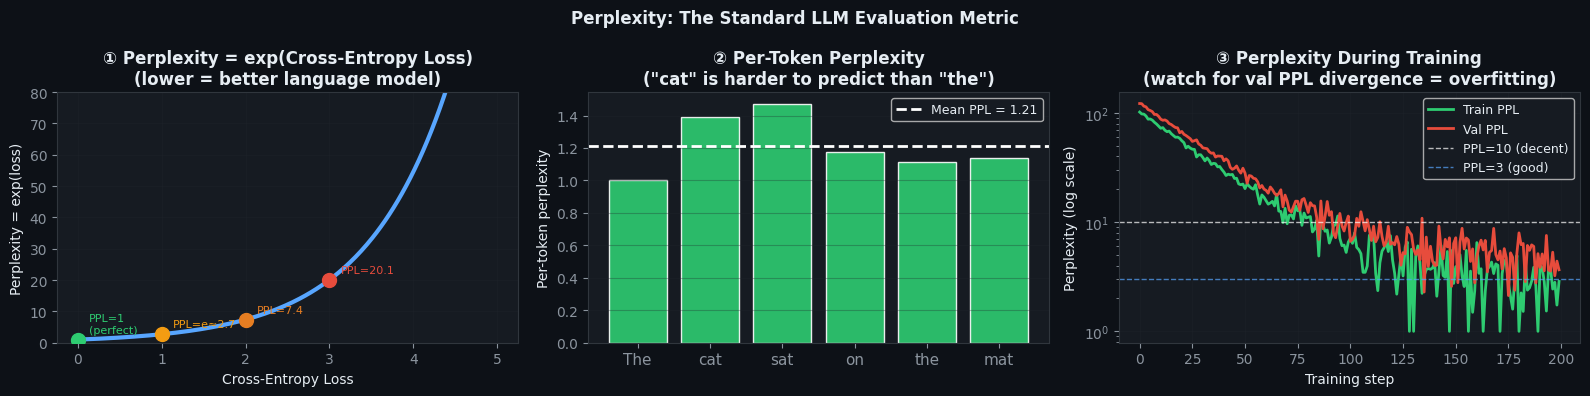

In [30]:
# ── Visualize perplexity ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Perplexity vs CE loss
ce_range   = np.linspace(0, 5, 300)
ppl_range  = np.exp(ce_range)
axes[0].plot(ce_range, ppl_range, '#58a6ff', lw=3)
key_points = [(0,'#2ECC71','PPL=1\n(perfect)'),(1,'#F39C12','PPL=e≈2.7'),(2,'#E67E22','PPL=7.4'),(3,'#E74C3C','PPL=20.1')]
for ce_val, col, lbl in key_points:
    ppl_val = np.exp(ce_val)
    axes[0].scatter([ce_val], [ppl_val], color=col, s=100, zorder=5)
    axes[0].annotate(lbl, (ce_val, ppl_val), textcoords='offset points',
                   xytext=(8, 5), fontsize=8, color=col)
axes[0].set_xlabel('Cross-Entropy Loss')
axes[0].set_ylabel('Perplexity = exp(loss)')
axes[0].set_title('① Perplexity = exp(Cross-Entropy Loss)\n(lower = better language model)', fontweight='bold')
axes[0].set_ylim(0, 80); axes[0].grid(True, alpha=0.3)

# 2. Per-token perplexity
token_list = ['The', 'cat', 'sat', 'on', 'the', 'mat']
per_tok_probs = [1.0, 0.72, 0.68, 0.85, 0.90, 0.88]  # probability of each true token
per_tok_ppl   = [1/p for p in per_tok_probs]  # per-token perplexity

bar_cols_ppl = ['#2ECC71' if p < 2 else '#F39C12' if p < 3 else '#E74C3C' for p in per_tok_ppl]
axes[1].bar(range(len(token_list)), per_tok_ppl, color=bar_cols_ppl, alpha=0.9, edgecolor='white')
axes[1].axhline(np.mean(per_tok_ppl), color='white', ls='--', lw=2,
               label=f'Mean PPL = {np.mean(per_tok_ppl):.2f}')
axes[1].set_xticks(range(len(token_list)))
axes[1].set_xticklabels(token_list, fontsize=11)
axes[1].set_ylabel('Per-token perplexity')
axes[1].set_title('② Per-Token Perplexity\n("cat" is harder to predict than "the")', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, axis='y', alpha=0.3)

# 3. Perplexity as training proxy
steps3 = np.arange(200)
ppl_train = 100 * np.exp(-steps3/30) + 3 + np.random.randn(200)*1.5
ppl_val   = 120 * np.exp(-steps3/30) + 5 + np.random.randn(200)*1.8

axes[2].semilogy(steps3, np.maximum(ppl_train, 1), '#2ECC71', lw=2, label='Train PPL')
axes[2].semilogy(steps3, np.maximum(ppl_val, 1),   '#E74C3C', lw=2, label='Val PPL')
axes[2].axhline(10, color='white', ls='--', lw=1, alpha=0.7, label='PPL=10 (decent)')
axes[2].axhline(3, color='#58a6ff', ls='--', lw=1, alpha=0.7, label='PPL=3 (good)')
axes[2].set_xlabel('Training step')
axes[2].set_ylabel('Perplexity (log scale)')
axes[2].set_title('③ Perplexity During Training\n(watch for val PPL divergence = overfitting)', fontweight='bold')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.suptitle('Perplexity: The Standard LLM Evaluation Metric', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 📊 Chapter 15: Scaling Laws
### How model size, data, and compute relate — the Chinchilla result

In [31]:
# ── What are scaling laws? ────────────────────────────────────────────────────
# Loss is a power-law function of model size (N), dataset size (D), and compute (C):
#
#   L(N) ≈ (N_c / N)^α_N    (more params → better)
#   L(D) ≈ (D_c / D)^α_D    (more data → better)
#   L(C) ≈ (C_c / C)^α_C    (more compute → better)
#
# Kaplan et al. 2020 (OpenAI): Model size matters most. Scale N first.
#   → This led to GPT-3 (175B params, 300B tokens)
#
# Hoffmann et al. 2022 (DeepMind, Chinchilla paper):
#   For a given compute budget, optimal split is:
#     N_optimal ∝ C^0.5   (√compute for model size)
#     D_optimal ∝ C^0.5   (√compute for data size)
#   → Optimal: 20 tokens per parameter
#   → GPT-3 was UNDERTRAINED (too big model, not enough data)
#   → Chinchilla (70B, 1.4T tokens) beats Gopher (280B, 300B tokens)

# Simulate scaling law curves
def loss_power_law(N, alpha=0.076, N_c=8.8e13):
    """Loss as a function of model parameters N (Kaplan et al.)."""
    return (N_c / N) ** alpha

def loss_chinchilla(N, D, alpha_N=0.34, alpha_D=0.28):
    """Simplified Chinchilla-style loss function of N and D."""
    # True formula is more complex; this captures the key insight
    return 1.69 + (6.1e18 / N) ** alpha_N + (1.8e22 / D) ** alpha_D

# Parameter counts (in millions)
N_range = np.logspace(7, 11, 100)  # 10M to 100B

print('📊 Chinchilla Scaling Law — Optimal Tokens per Parameter:')
print('\nModel sizes and their Chinchilla-optimal token counts:')
models_sc = [
    ('GPT-2',      117e6,   2.46e9,   '40B'),
    ('GPT-3',      175e9,   3.67e12,  '3.7T (actually trained on 300B!)'),
    ('LLaMA-7B',   7e9,     1.47e11,  '140B (actually trained on 1T!)'),
    ('LLaMA-70B',  70e9,    1.47e12,  '1.4T (matches Chinchilla!)'),
    ('Claude 3',   20e9,   4e11,    '~400B (estimated)'),
]

print(f'\n{"Model":<12} | {"Params":>12} | {"Chinchilla Optimal (×20)"}  ')
print('-' * 55)
for name, N, D_opt, note in models_sc:
    n_str = f'{N/1e9:.0f}B' if N >= 1e9 else f'{N/1e6:.0f}M'
    print(f'{name:<12} | {n_str:>12} | {note}')

print()
print('💡 Chinchilla insight:')
print('   Old thinking: bigger model = better')
print('   New thinking: for fixed compute, train a smaller model on MORE data')
print('   Rule of thumb: 20 tokens per parameter is optimal')
print('   Example: 7B model → should see 140B tokens')

📊 Chinchilla Scaling Law — Optimal Tokens per Parameter:

Model sizes and their Chinchilla-optimal token counts:

Model        |       Params | Chinchilla Optimal (×20)  
-------------------------------------------------------
GPT-2        |         117M | 40B
GPT-3        |         175B | 3.7T (actually trained on 300B!)
LLaMA-7B     |           7B | 140B (actually trained on 1T!)
LLaMA-70B    |          70B | 1.4T (matches Chinchilla!)
Claude 3     |          20B | ~400B (estimated)

💡 Chinchilla insight:
   Old thinking: bigger model = better
   New thinking: for fixed compute, train a smaller model on MORE data
   Rule of thumb: 20 tokens per parameter is optimal
   Example: 7B model → should see 140B tokens


/tmp/ipykernel_7667/3881956533.py:75: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7667/3881956533.py:75: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7667/3881956533.py:75: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7667/3881956533.py:75: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7667/3881956533.py:75: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7667/3881956533.py:75: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7667/3881956533.py:75: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist

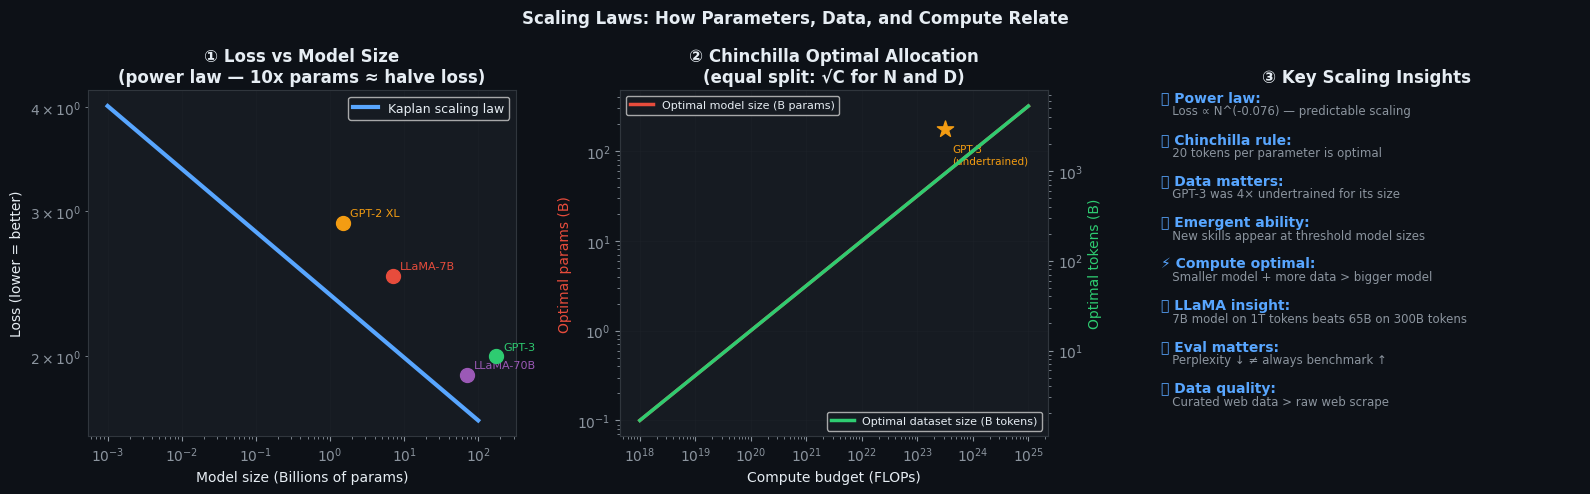

In [32]:
# ── Visualize scaling laws ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Loss vs model size (power law)
N_vals  = np.logspace(6, 11, 200)  # 1M to 100B params
L_N     = loss_power_law(N_vals)

axes[0].loglog(N_vals/1e9, L_N, '#58a6ff', lw=3, label='Kaplan scaling law')

real_models = [
    ('GPT-2 XL', 1.5e9, 2.9, '#F39C12'),
    ('GPT-3', 175e9, 2.0, '#2ECC71'),
    ('LLaMA-7B', 7e9, 2.5, '#E74C3C'),
    ('LLaMA-70B', 70e9, 1.9, '#9B59B6'),
]
for name, N_m, L_m, col in real_models:
    axes[0].scatter([N_m/1e9], [L_m], color=col, s=100, zorder=5)
    axes[0].annotate(name, (N_m/1e9, L_m), textcoords='offset points',
                   xytext=(5, 5), fontsize=8, color=col)

axes[0].set_xlabel('Model size (Billions of params)')
axes[0].set_ylabel('Loss (lower = better)')
axes[0].set_title('① Loss vs Model Size\n(power law — 10x params ≈ halve loss)', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# 2. Chinchilla optimal compute allocation
compute_budgets = np.logspace(18, 25, 100)  # FLOPs
# Optimal N and D for each compute budget (Chinchilla formula)
N_opt = 0.1 * compute_budgets ** 0.5
D_opt = compute_budgets / (6 * N_opt)  # C ≈ 6*N*D for transformer training

ax2a = axes[1]
ax2b = ax2a.twinx()
ax2a.loglog(compute_budgets, N_opt/1e9, '#E74C3C', lw=2.5, label='Optimal model size (B params)')
ax2b.loglog(compute_budgets, D_opt/1e9, '#2ECC71', lw=2.5, label='Optimal dataset size (B tokens)')

# Mark GPT-3 and Chinchilla
ax2a.scatter([3.14e23/1e0], [175], color='#F39C12', s=150, zorder=5, marker='*')
ax2a.annotate('GPT-3\n(undertrained)', xy=(3.14e23,175), fontsize=7.5, color='#F39C12',
             xytext=(5, -25), textcoords='offset points')

ax2a.set_xlabel('Compute budget (FLOPs)')
ax2a.set_ylabel('Optimal params (B)', color='#E74C3C')
ax2b.set_ylabel('Optimal tokens (B)', color='#2ECC71')
axes[1].set_title('② Chinchilla Optimal Allocation\n(equal split: √C for N and D)', fontweight='bold')
ax2a.legend(loc='upper left', fontsize=8)
ax2b.legend(loc='lower right', fontsize=8)
axes[1].grid(True, alpha=0.3)

# 3. Summary table as a chart
ax3 = axes[2]
ax3.axis('off')
ax3.set_title('③ Key Scaling Insights', fontweight='bold')

insights = [
    ('📏', 'Power law', 'Loss ∝ N^(-0.076) — predictable scaling'),
    ('🎯', 'Chinchilla rule', '20 tokens per parameter is optimal'),
    ('💡', 'Data matters', 'GPT-3 was 4× undertrained for its size'),
    ('🚀', 'Emergent ability', 'New skills appear at threshold model sizes'),
    ('⚡', 'Compute optimal', 'Smaller model + more data > bigger model'),
    ('📊', 'LLaMA insight', '7B model on 1T tokens beats 65B on 300B tokens'),
    ('🔬', 'Eval matters', 'Perplexity ↓ ≠ always benchmark ↑'),
    ('🌐', 'Data quality', 'Curated web data > raw web scrape'),
]

for i, (icon, title, detail) in enumerate(insights):
    y = 1.0 - i * 0.12
    ax3.text(0.02, y, f'{icon} {title}:', transform=ax3.transAxes,
            fontsize=10, fontweight='bold', color='#58a6ff', va='top')
    ax3.text(0.02, y-0.04, f'   {detail}', transform=ax3.transAxes,
            fontsize=8.5, color='#8b949e', va='top')

plt.suptitle('Scaling Laws: How Parameters, Data, and Compute Relate',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 🏁 Complete Reference Summary

| Concept | Formula / Key Rule | LLM Usage |
|---------|--------------------|-----------|
| **Matrix Multiply** | `C[i,j] = Σ A[i,k]·B[k,j]` | Every single layer |
| **Dot Product** | `a·b = Σ aᵢbᵢ = \|a\|\|b\|cos(θ)` | Attention scores Q·K |
| **Cosine Similarity** | `a·b / (\|a\|·\|b\|)` | Embedding similarity |
| **Embeddings** | Lookup table: token ID → dense vector | Input to every transformer |
| **Softmax** | `exp(xᵢ) / Σ exp(xⱼ)` | Attention weights, output probs |
| **Temperature** | `softmax(x/T)` — T↑ = more random | Generation creativity |
| **Cross-Entropy** | `-log P(correct class)` | Training loss |
| **Backprop** | Chain rule: `dL/dW = dL/dy × dy/dW` | How weights learn |
| **Gradient Descent** | `w = w - lr × dL/dw` | Weight update rule |
| **Weight Init** | He: `σ=√(2/fan_in)` | Prevents vanishing/exploding |
| **RMSNorm** | `x / RMS(x) × γ` | Activation stabilization |
| **Self-Attention** | `softmax(QKᵀ/√dₖ)V` | Context aggregation |
| **AdamW** | Adaptive LR + weight decay | Standard LLM optimizer |
| **LR Schedule** | Warmup + cosine decay | Training stability |
| **Tokenization** | BPE subword merges | Text → IDs |
| **Perplexity** | `exp(avg CE loss)` | LLM evaluation metric |
| **Scaling Laws** | `L ∝ N^(-0.076)` | 20 tokens per param optimal |

---
*Built for SkillWisor — the complete LLM math foundation in one notebook 🇮🇳*